# COMP 333 — Final Project

# Montreal Bixi Mobility & Climate Analysis (2025)

## Project Overview

This project synthesizes over 2 GB of raw Bixi Trip History with hourly meteorological data from Environment Canada to investigate how Montreal's climate influences urban cycling behaviour. The pipeline transitions from raw, high-volume data to a suite of supervised and unsupervised machine learning models, culminating in a fully interpreted classification system.

**Primary Objective:**

To determine whether environmental and temporal features can reliably classify Bixi trips as Short, Medium, or Long — and to identify which factors are the strongest predictors of trip-duration category in Montreal's bike-share network.

---

## Data Sources

**Main Dataset:**
- Bixi 2025 Trip History: 11.5 M trip records reflecting the most recent densified network. Source: https://bixi.com/en/open-data/

**Supporting Dataset:**
- Environment Canada Hourly Climate Data: Provides hourly temperature, precipitation, and windchill readings. Source: https://climate-change.canada.ca/climate-data/#/hourly-climate-data

### Why This Dataset?

**Scale:** The 2025 Bixi dataset exceeds 2 GB and 11 million rows, providing a genuine big-data challenge for pipeline design.

**Complexity:** Raw data requires significant programmatic handling — 13-digit Unix millisecond timestamps, coordinate gaps, ghost trips, and cross-file weather joins.

**Urban Context:** Montreal's extreme climate (−35°C winters, 35°C summers, heavy precipitation) provides a natural laboratory for testing how environmental shocks influence rider behaviour.

---

## Project Roadmap

### Phase 1: Foundation & Baseline

- **Data Retrieval & Integration:** Programmatic retrieval and synchronisation of Bixi trip records and Environment Canada hourly climate data.
- **Audit & Wrangling:** Pre- and post-cleaning quantitative and visual audits using `quantDDA()` and `vizDDA()`. Temporal alignment via Unix-millisecond conversion and weather join on rounded hour.
- **Regression Baseline:** Linear Regression and Decision Tree Regressor on weather features only, establishing a performance floor (R² ≈ 0.005) that motivates the Phase 2 classification reframing.

### Phase 2: Advanced Modeling & Feature Engineering

- **Problem Reframing:** Target converted to a 3-class variable (`duration_cat`) using data-driven tertile boundaries, ensuring balanced classes (~33% each).
- **Advanced Supervised Learning:** Three classifiers — Random Forest, LightGBM, and Linear SVC — evaluated first on baseline features, then on the full engineered feature set with systematic hyperparameter tuning. Evaluated by Accuracy, Macro F1, and ROC-AUC (OVR).
- **Feature Engineering & Selection:** 15 temporal, cyclical, interaction, and weather features engineered; ranked by mutual information (filter), RFE with LinearSVC (wrapper), and Random Forest impurity (embedded).
- **Unsupervised Learning:** PCA for dimensionality reduction and K-Means clustering to discover behavioural trip personas without using the class label.
- **Interpretation:** Feature importance (Random Forest and LightGBM) and Partial Dependence Plots to explain what the best model learned.

---

## Team & Division of Labour

**Phase 1**

| Name | Student ID | Contribution |
|------|------------|--------------|
| Gorden | 40263250 | GitHub repository & version control; baseline models (Linear Regression, Decision Tree) |
| Omar Benjelloun | 40215107 | Data retrieval, wrangling & cleaning pipeline, EDA |

**Phase 2**

| Name | Student ID | Contribution |
|------|------------|--------------|
| Gorden | 40263250 | Advanced supervised learning — Random Forest (implementation, tuning, evaluation); feature engineering (temporal, cyclical & interaction features, feature selection); unsupervised learning — PCA (dimensionality reduction, scree plot, variance analysis) |
| Omar Benjelloun | 40215107 | Advanced supervised learning — LightGBM & Linear SVC (implementation, tuning, evaluation); unsupervised learning — K-Means clustering (optimal k selection, cluster visualisation, profile analysis); model interpretation (feature importance, partial dependence plots, insights) |

**Note:** While responsibilities were divided, both team members were involved in all stages to maintain a shared understanding of the full pipeline.


---

## Table of Contents

### Phase 1: Data Acquisition & Baseline

#### [1. Data Retrieval](#1-data-retrieval)
- [1.1 Importing Modules & File Paths](#11-importing-modules--file-paths)

#### [2. Wrangling & Cleaning](#2-wrangling--cleaning)
- [2.1 Initial Audit of Raw Data](#21-initial-audit-of-raw-data)
  - [2.1.1 Raw Bixi Dataset Exploration](#211-raw-bixi-dataset-exploration)
  - [2.1.2 Raw Weather Dataset Exploration](#212-raw-weather-dataset-exploration)
  - [2.1.3 Raw Datasets Analysis](#213-raw-datasets-analysis)
- [2.2 Programmatic Acquisition & Wrangling](#22-programmatic-acquisition--wrangling)
- [2.3 Post-Wrangling Audit & Sample Display](#23-post-wrangling-audit--sample-display)

#### [3. Exploratory Data Analysis](#3-exploratory-data-analysis-eda)
- [3.1 Visualizations](#31-visualizations-vizdda)
- [3.2 Post-Wrangling Visual & Quantitative Audit](#32-post-wrangling-visual--quantitative-audit)
- [3.3 Research Formulation](#33-research-formulation)

#### [4. Baseline Model & Analysis](#4-baseline-model--analysis)
- [4.1 Models Rationale](#41-models-rationale)
- [4.2 Models Implementation](#42-models-implementation)
- [4.3 Results & Evaluation](#43-results--evaluation)
- [4.4 References](#44-references)

---

### Phase 2: Advanced Modeling & Feature Engineering

#### [1. Advanced Supervised Learning — Baseline](#1-advanced-supervised-learning--baseline)
- [1.1 Random Forest](#11-random-forest)
- [1.2 LightGBM](#12-lightgbm)
- [1.3 Linear SVC](#13-linear-svc)
- [1.4 Baseline Comparison](#14-baseline-comparison)

#### [2. Feature Engineering & Selection](#2-feature-engineering--selection)
- [2.1 New Features](#21-new-features)
- [2.2 Feature Selection](#22-feature-selection)

#### [3. Advanced Supervised Learning — Engineered Features](#3-advanced-supervised-learning--engineered-features)
- [3.1 Random Forest](#31-random-forest)
- [3.2 LightGBM](#32-lightgbm)
- [3.3 Linear SVC](#33-linear-svc)
- [3.4 Systematic Comparison & Best Model Selection](#34-systematic-comparison--best-model-selection)

#### [4. Unsupervised Learning](#4-unsupervised-learning)
- [4.1 PCA — Dimensionality Reduction](#41-pca--dimensionality-reduction)
- [4.2 K-Means — Optimal Cluster Selection](#42-k-means--optimal-cluster-selection)
- [4.3 Cluster Visualisation & Profiles](#43-cluster-visualisation--profiles)
- [4.4 Cluster Quality & Justification](#44-cluster-quality--justification)

#### [5. Interpretation](#5-interpretation)
- [5.1 Feature Importance](#51-feature-importance)
- [5.2 Partial Dependence Plots](#52-partial-dependence-plots)
- [5.3 Insights & Conclusions](#53-insights--conclusions)


# Phase 1: Data Acquisition & Baseline

---

## 1. Data Retrieval



### 1.1 Importing Modules & File Paths

In [1]:
# ── All imports, constants, and shared helpers ───────────────────────────────
# Run this cell first — every other cell in the notebook depends on it.
import os, sys, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
from IPython.display import display
warnings.filterwarnings('ignore')

# Model selection utilities
from sklearn.model_selection import (
    train_test_split, RandomizedSearchCV, GridSearchCV, StratifiedKFold
)

# Phase 1 — regression imports
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Phase 2 — classification imports
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay, roc_curve
)
from sklearn.feature_selection import RFE, mutual_info_classif
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.inspection import PartialDependenceDisplay

# Global random seed — ensures all stochastic operations are reproducible
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# ── Phase 1 regression helper ─────────────────────────────────────────────────
# Returns [RMSE, MAE, R²] for any fitted regressor on a given (X, y) split.
METRICS_REG = ['RMSE (Minutes)', 'MAE (Minutes)', 'R² Score']

def evaluate_reg(model, X, y):
    p = model.predict(X)
    return [
        np.sqrt(mean_squared_error(y, p)),
        mean_absolute_error(y, p),
        r2_score(y, p)
    ]

# ── Phase 2 classification helper ────────────────────────────────────────────
# Returns [Accuracy, Macro F1, ROC-AUC (OVR)] for any fitted classifier.
# Macro F1 weights all three classes equally — appropriate for balanced classes.
# ROC-AUC uses One-vs-Rest (OVR) strategy for multi-class evaluation.
METRICS = ['Accuracy', 'Macro F1', 'ROC-AUC (OVR)']
CLASS_NAMES = ['Short', 'Medium', 'Long']  # placeholder — overwritten in Phase 2 new001 with data-driven tertile labels

def _softmax(Z):
    # Converts raw decision function scores to pseudo-probabilities that sum to 1.
    # Required for LinearSVC, which does not have predict_proba().
    e = np.exp(Z - Z.max(axis=1, keepdims=True))
    return e / e.sum(axis=1, keepdims=True)

def evaluate_model(model, X, y):
    p   = model.predict(X)
    acc = accuracy_score(y, p)
    f1  = f1_score(y, p, average='macro')
    try:
        scores = model.predict_proba(X)
    except AttributeError:
        # LinearSVC does not expose predict_proba; softmax-normalise decision scores
        scores = _softmax(model.decision_function(X))
    auc = roc_auc_score(y, scores, multi_class='ovr', average='macro')
    return [acc, f1, auc]

# ── Local module imports ──────────────────────────────────────────────────────
# src/wrangle.py — data cleaning and weather loading functions
# src/analysis.py — quantitative and visual audit helpers (quantDDA, vizDDA)
sys.path.append(os.path.abspath('../src'))
from wrangle import wrangle_bixi_chunk, load_and_filter_weather
from analysis import quantDDA, vizDDA

# ── File paths ────────────────────────────────────────────────────────────────
RAW_BIXI       = '../data/raw/Bixi2025.csv'
RAW_WEATHER_1  = '../data/raw/HourlyClimate - JanToMar.csv'
RAW_WEATHER_2  = '../data/raw/HourlyClimate- MarToDec.csv'
PROCESSED_PATH = '../data/processed/bixi_weather_2025.csv'


---

## 2. Wrangling & Cleaning


### 2.1 Initial Audit of Raw Data

In [2]:
# Function to show the Sandwich view (Top 5 + Bottom 5)
def display_extremes(df, num=5):
    return pd.concat([df.head(num), df.tail(num)])
    



#### 2.1.1 Raw Bixi Dataset Exploration

In [3]:
# --- AUDIT 1: Raw Bixi ---

print("\n--- AUDIT 1: Raw Bixi (Head & Tail Sample) ---")

# Counting raw Bixi rows without crashing RAM
raw_row_count = 0
for chunk in pd.read_csv(RAW_BIXI, chunksize=500000, usecols=[0]):
    raw_row_count += len(chunk)
print(f"\nInitial Dataset Size: {raw_row_count:,} rows\n")

df_raw_bixi_sample = pd.read_csv(RAW_BIXI, nrows=100000) 

# ANOMALIES: 
# - 'STARTTIMEMS' values like 1741120... are 13-digit Unix Milliseconds (needs conversion).
# -  Look for rows where STARTTIMEMS == ENDTIMEMS (0-second 'Ghost' trips).
display(display_extremes(df_raw_bixi_sample))

print("\nRunning quantDDA on raw dataset:")
display(quantDDA(df_raw_bixi_sample))


--- AUDIT 1: Raw Bixi (Head & Tail Sample) ---

Initial Dataset Size: 14,249,363 rows



,STARTSTATIONNAME,STARTSTATIONARRONDISSEMENT,STARTSTATIONLATITUDE,STARTSTATIONLONGITUDE,ENDSTATIONNAME,ENDSTATIONARRONDISSEMENT,ENDSTATIONLATITUDE,ENDSTATIONLONGITUDE,STARTTIMEMS,ENDTIMEMS
0,Parc Émilie-Gamelin (St-Hubert / de Maisonneuv...,Ville-Marie,45.515868,-73.560084,NaN,NaN,NaN,NaN,1741120865258,NaN
1,Métro Mont-Royal (Utilités publiques / Rivard),Le Plateau-Mont-Royal,45.524247,-73.581662,NaN,NaN,NaN,NaN,1741144108111,NaN
2,Notre-Dame / St-Martin,Le Sud-Ouest,45.488302,-73.568718,NaN,NaN,NaN,NaN,1741094909506,NaN
3,de Maisonneuve / Greene,Westmount,45.486971,-73.589293,NaN,NaN,NaN,NaN,1741098869605,NaN
4,Métro Sherbrooke (de Rigaud / Berri),Le Plateau-Mont-Royal,45.518143,-73.568004,NaN,NaN,NaN,NaN,1741094527644,NaN
99995,de Gaspé / St-Viateur,Le Plateau-Mont-Royal,45.527792,-73.597608,de Mentana / Roy,Le Plateau-Mont-Royal,45.522113,-73.569464,1758802296503,1.758803e+12
99996,Drolet / Beaubien,Rosemont - La Petite-Patrie,45.533348,-73.605834,de Mentana / Roy,Le Plateau-Mont-Royal,45.522113,-73.569464,1758575453656,1.758577e+12
99997,Laurier / Chabot,Le Plateau-Mont-Royal,45.537072,-73.579331,de Mentana / Roy,Le Plateau-Mont-Royal,45.522113,-73.569464,1758906820830,1.758908e+12
99998,Casgrain / Maguire,Le Plateau-Mont-Royal,45.526218,-73.595766,de Mentana / Roy,Le Plateau-Mont-Royal,45.522113,-73.569464,1758206932468,1.758207e+12
99999,Casgrain / Maguire,Le Plateau-Mont-Royal,45.526218,-73.595766,de Mentana / Roy,Le Plateau-Mont-Royal,45.522113,-73.569464,1758215218459,1.758216e+12



Running quantDDA on raw dataset:


,Total Obs,Missing,Unique,Outliers (IQR),Mode,Mean,StdDev,Min,Median,Max,Skew
Feature,,,,,,,,,,,
STARTSTATIONNAME,100000,0,1113,NaN,Laurier / St-Denis,NaN,NaN,NaN,NaN,NaN,NaN
STARTSTATIONARRONDISSEMENT,100000,0,31,NaN,Le Plateau-Mont-Royal,NaN,NaN,NaN,NaN,NaN,NaN
STARTSTATIONLATITUDE,100000,0,1154,1841.0,45.5271540234837,4.552094e+01,2.398283e-02,4.538016e+01,4.552410e+01,4.569223e+01,-0.338112
STARTSTATIONLONGITUDE,100000,0,1148,5820.0,-73.58943924307823,-7.357836e+01,3.342499e-02,-7.392122e+01,-7.357589e+01,-7.187564e+01,23.598978
ENDSTATIONNAME,100000,6008,130,NaN,Sherbrooke / Jeanne-d'Arc,NaN,NaN,NaN,NaN,NaN,NaN
ENDSTATIONARRONDISSEMENT,100000,6008,24,NaN,Le Plateau-Mont-Royal,NaN,NaN,NaN,NaN,NaN,NaN
ENDSTATIONLATITUDE,100000,6008,133,252.0,45.55398156058887,4.552323e+01,2.474415e-02,4.539094e+01,4.552743e+01,4.563147e+01,-0.384514
ENDSTATIONLONGITUDE,100000,6008,133,3395.0,-73.55496388156098,-7.357319e+01,2.847526e-02,-7.390966e+01,-7.357042e+01,-7.187262e+01,18.577879
STARTTIMEMS,100000,0,99991,5590.0,"1748380799309, 1748381030746, 1748381756859, 1...",1.761678e+12,3.679502e+09,1.736851e+12,1.762955e+12,1.767243e+12,-1.767400




#### 2.1.2 Raw Weather Dataset Exploration

In [4]:
# --- AUDIT 2: Raw Weather ---
print("\n--- AUDIT 2: Raw Weather (Head & Tail Sample) ---")
df_w_raw = pd.concat([
    pd.read_csv(RAW_WEATHER_1, nrows=1000), 
    pd.read_csv(RAW_WEATHER_2, nrows=1000)
])

# ANOMALIES: 
# - 'LOCAL_DATE' may show years like 2024 or 2026 (outside 2025 Bixi season).
# -  High number of redundant columns (e.g., Visibility, Pressure) not needed for our hypothesis.
display(display_extremes(df_w_raw))

print("\nRunning quantDDA on raw dataset:")
display(quantDDA(df_w_raw))



--- AUDIT 2: Raw Weather (Head & Tail Sample) ---


,x,y,STATION_NAME,CLIMATE_IDENTIFIER,ID,LOCAL_DATE,PROVINCE_CODE,LOCAL_YEAR,LOCAL_MONTH,LOCAL_DAY,...,WEATHER_FRE_DESC,WINDCHILL,WINDCHILL_FLAG,WIND_DIRECTION,WIND_DIRECTION_FLAG,WIND_SPEED,WIND_SPEED_FLAG,STN_ID,LONGITUDE_DECIMAL_DEGREES,LATITUDE_DECIMAL_DEGREES
0,-73.741667,45.467778,MONTREAL/PIERRE ELLIOTT TRUDEAU INTL,702S006,702S006.2024.2.6.19,2024-02-06 19:00:00,QC,2024,2,6,...,ND,-5.0,NaN,30,NaN,3,NaN,30165,-73.741667,45.467778
1,-73.741667,45.467778,MONTREAL/PIERRE ELLIOTT TRUDEAU INTL,702S006,702S006.2024.2.6.20,2024-02-06 20:00:00,QC,2024,2,6,...,ND,NaN,NaN,0,NaN,0,NaN,30165,-73.741667,45.467778
2,-73.741667,45.467778,MONTREAL/PIERRE ELLIOTT TRUDEAU INTL,702S006,702S006.2024.2.6.21,2024-02-06 21:00:00,QC,2024,2,6,...,ND,-5.0,NaN,36,NaN,3,NaN,30165,-73.741667,45.467778
3,-73.741667,45.467778,MONTREAL/PIERRE ELLIOTT TRUDEAU INTL,702S006,702S006.2024.2.6.22,2024-02-06 22:00:00,QC,2024,2,6,...,ND,-6.0,NaN,35,NaN,4,NaN,30165,-73.741667,45.467778
4,-73.741667,45.467778,MONTREAL/PIERRE ELLIOTT TRUDEAU INTL,702S006,702S006.2024.2.6.23,2024-02-06 23:00:00,QC,2024,2,6,...,ND,NaN,NaN,0,NaN,0,NaN,30165,-73.741667,45.467778
995,-73.741667,45.467778,MONTREAL/PIERRE ELLIOTT TRUDEAU INTL,702S006,702S006.2025.5.10.13,2025-05-10 13:00:00,QC,2025,5,10,...,ND,NaN,NaN,25,NaN,4,NaN,30165,-73.741667,45.467778
996,-73.741667,45.467778,MONTREAL/PIERRE ELLIOTT TRUDEAU INTL,702S006,702S006.2025.5.10.14,2025-05-10 14:00:00,QC,2025,5,10,...,ND,NaN,NaN,19,NaN,7,NaN,30165,-73.741667,45.467778
997,-73.741667,45.467778,MONTREAL/PIERRE ELLIOTT TRUDEAU INTL,702S006,702S006.2025.5.10.15,2025-05-10 15:00:00,QC,2025,5,10,...,ND,NaN,NaN,21,NaN,11,NaN,30165,-73.741667,45.467778
998,-73.741667,45.467778,MONTREAL/PIERRE ELLIOTT TRUDEAU INTL,702S006,702S006.2025.5.10.16,2025-05-10 16:00:00,QC,2025,5,10,...,ND,NaN,NaN,22,NaN,11,NaN,30165,-73.741667,45.467778
999,-73.741667,45.467778,MONTREAL/PIERRE ELLIOTT TRUDEAU INTL,702S006,702S006.2025.5.10.17,2025-05-10 17:00:00,QC,2025,5,10,...,ND,NaN,NaN,20,NaN,15,NaN,30165,-73.741667,45.467778



Running quantDDA on raw dataset:


,Total Obs,Missing,Unique,Outliers (IQR),Mode,Mean,StdDev,Min,Median,Max,Skew
Feature,,,,,,,,,,,
x,2000,0,1,0.0,-73.74166666666666,-73.741667,1.421441e-14,-73.741667,-73.741667,-73.741667,0.000000
y,2000,0,1,0.0,45.467777777777776,45.467778,7.107204e-15,45.467778,45.467778,45.467778,0.000000
STATION_NAME,2000,0,1,NaN,MONTREAL/PIERRE ELLIOTT TRUDEAU INTL,NaN,NaN,NaN,NaN,NaN,NaN
CLIMATE_IDENTIFIER,2000,0,1,NaN,702S006,NaN,NaN,NaN,NaN,NaN,NaN
ID,2000,0,2000,NaN,"702S006.2024.2.10.0, 702S006.2024.2.10.1, 702S...",NaN,NaN,NaN,NaN,NaN,NaN
LOCAL_DATE,2000,0,2000,NaN,"2024-02-06 19:00:00, 2024-02-06 20:00:00, 2024...",NaN,NaN,NaN,NaN,NaN,NaN
PROVINCE_CODE,2000,0,1,NaN,QC,NaN,NaN,NaN,NaN,NaN,NaN
LOCAL_YEAR,2000,0,2,0.0,"2024, 2025",2024.500000,5.001250e-01,2024.000000,2024.500000,2025.000000,0.000000
LOCAL_MONTH,2000,0,4,0.0,4,3.310000,1.001699e+00,2.000000,3.000000,5.000000,0.043356


---

#### 2.1.3 Raw Datasets Analysis

Before performing any transformations, we ran a Quantitative Audit on the raw Bixi and Weather datasets. The results revealed several critical issues that would compromise the integrity of our models if left unaddressed.

**Bixi Dataset Audit Results (Raw)**

The initial audit of the Bixi2025.csv file (over 14.2 million rows) highlighted three primary concerns:

Temporal Format Inconsistency: The STARTTIMEMS and ENDTIMEMS columns are stored as 13-digit Unix integers (milliseconds). Without conversion, these are mathematically unusable for duration or seasonal analysis.

Missing Critical Coordinates: Several thousand rows are missing STARTSTATIONLATITUDE or ENDSTATIONLONGITUDE. These "broken trips" would fail during our Phase 2 analysis.

Presence of "Ghost" and "Forgotten" Trips: The raw data contains trips with identical start/end times (0 seconds) and trips lasting several days. These represent system errors or unreturned bikes, not actual commuter behavior.

**Weather Dataset Audit Results (Raw)**

Combining the two climate files (JanToMar and MarToDec) revealed the following:

Date Range Overlap: The files contain data extending into late 2024 and early 2026. Since the Bixi season is strictly bound to 2025, this extra data creates unnecessary memory overhead and potential join errors.

Feature Redundancy: The original Environment Canada format includes over 20 columns (e.g., Visibility, Pressure, Humidex) that are either sparse or irrelevant to our specific hypothesis regarding temperature and precipitation.

Meteorological Logs: The quantDDA flagged no null entries in the TEMP feature and only 2 null entries PRECIP_AMOUNT columns. This would make the data reliable for phase 2.


---

### 2.2 Programmatic Acquisition & Wrangling #

Transforming the messy inputs into a clean analytical dataset.

In [5]:
# Wrangling is computationally expensive (~3 GB of raw CSV), so we cache the
# processed result. If the file already exists, load it directly; otherwise
# run the full cleaning and join pipeline and save the output.
if os.path.exists(PROCESSED_PATH):
    print('Processed file found. Loading from cache...')
    df_final = pd.read_csv(PROCESSED_PATH)
    print(f'Loaded: {df_final.shape[0]:,} rows, {df_final.shape[1]} columns')
else:
    print('No processed file found. Running full wrangling pipeline...')

    # Read raw Bixi CSV in chunks to avoid loading 14M rows into memory at once.
    # wrangle_bixi_chunk() converts timestamps, filters outliers, and computes duration.
    chunks = []
    for chunk in pd.read_csv(RAW_BIXI, chunksize=100000):
        chunks.append(wrangle_bixi_chunk(chunk))
    df_bixi = pd.concat(chunks)

    # Load and filter the two hourly weather files to the 2025 season.
    df_weather = load_and_filter_weather(RAW_WEATHER_1, RAW_WEATHER_2)
    df_weather['LOCAL_DATE'] = pd.to_datetime(df_weather['LOCAL_DATE']).dt.tz_localize(None)

    # Left-join each trip to its corresponding hourly weather observation.
    # Trips with no matching weather record (no-show hours) are dropped.
    df_final = pd.merge(df_bixi, df_weather, left_on='hour_rounded', right_on='LOCAL_DATE', how='left')
    df_final.drop(columns=['LOCAL_DATE'], inplace=True)
    df_final = df_final.dropna(subset=['TEMP']).copy()

    print(f'Wrangling complete. Final dataset: {df_final.shape[0]:,} trips.')
    df_final.to_csv(PROCESSED_PATH, index=False)
    print('Saved to data/processed/')


Processed file found. Loading from cache...
Loaded: 11,546,527 rows, 15 columns


---

### 2.3 Post-Wrangling Audit & Sample Display

In [6]:
print("\n--- FINAL AUDIT OF CLEANED DATASETS  ---")

print("\n Bixi & Weather Head & Tail Sample")
display(display_extremes(df_final))



print("--- FINAL QUANTITATIVE AUDIT (Processed) ---")

print("\n Bixi & Weather Quantitative Audit")
display(quantDDA(df_final))


--- FINAL AUDIT OF CLEANED DATASETS  ---

 Bixi & Weather Head & Tail Sample


,STARTSTATIONNAME,STARTSTATIONARRONDISSEMENT,STARTSTATIONLATITUDE,STARTSTATIONLONGITUDE,ENDSTATIONNAME,ENDSTATIONARRONDISSEMENT,ENDSTATIONLATITUDE,ENDSTATIONLONGITUDE,start_dt,end_dt,hour_rounded,duration_min,TEMP,PRECIP_AMOUNT,WINDCHILL
0,St-Viateur / Casgrain,Le Plateau-Mont-Royal,45.527013,-73.597973,Parc Molson (d'Iberville / Beaubien),Rosemont - La Petite-Patrie,45.549022,-73.591982,2025-12-30 13:20:45.159,2025-12-30 13:38:47.367,2025-12-30 13:00:00,18.036800,-12.7,0.0,-23.0
1,9e avenue / Masson,Rosemont - La Petite-Patrie,45.549490,-73.573272,Parc Molson (d'Iberville / Beaubien),Rosemont - La Petite-Patrie,45.549022,-73.591982,2025-12-30 21:09:27.447,2025-12-30 21:27:34.129,2025-12-30 21:00:00,18.111367,-14.3,0.0,-25.0
2,St-Urbain / Laurier,Le Plateau-Mont-Royal,45.521711,-73.593743,Parc Molson (d'Iberville / Beaubien),Rosemont - La Petite-Patrie,45.549022,-73.591982,2025-12-27 15:25:49.246,2025-12-27 15:44:35.435,2025-12-27 15:00:00,18.769817,-9.0,0.0,-14.0
3,Parc de Turin (de Lanaudière / Jean-Talon),Villeray—Saint-Michel—Parc-Extension,45.545350,-73.610330,Parc Molson (d'Iberville / Beaubien),Rosemont - La Petite-Patrie,45.549022,-73.591982,2025-12-31 19:31:48.567,2025-12-31 19:43:29.866,2025-12-31 20:00:00,11.688317,-8.8,0.0,-11.0
4,Parthenais / du Mont-Royal,Le Plateau-Mont-Royal,45.536404,-73.571413,Parc Molson (d'Iberville / Beaubien),Rosemont - La Petite-Patrie,45.549022,-73.591982,2025-12-28 15:29:24.324,2025-12-28 15:46:38.356,2025-12-28 15:00:00,17.233867,-7.0,0.0,-13.0
11546522,Marquette / du Mont-Royal (sud),Le Plateau-Mont-Royal,45.532077,-73.575143,Bennett / Ste-Catherine,Mercier - Hochelaga-Maisonneuve,45.553159,-73.532633,2025-12-22 18:41:43.350,2025-12-22 19:05:50.004,2025-12-22 19:00:00,24.110900,-7.1,0.0,-10.0
11546523,Parc André-Lavallée (Laurier),Rosemont - La Petite-Patrie,45.553320,-73.569328,Bennett / Ste-Catherine,Mercier - Hochelaga-Maisonneuve,45.553159,-73.532633,2025-12-22 17:39:13.753,2025-12-22 17:58:07.035,2025-12-22 18:00:00,18.888033,-7.3,0.2,-9.0
11546524,Bernard / Jeanne-Mance,Le Plateau-Mont-Royal,45.524296,-73.604912,Bennett / Ste-Catherine,Mercier - Hochelaga-Maisonneuve,45.553159,-73.532633,2025-12-18 23:57:28.066,2025-12-19 00:40:29.153,2025-12-19 00:00:00,43.018117,5.4,0.0,NaN
11546525,Bernard / Jeanne-Mance,Le Plateau-Mont-Royal,45.524296,-73.604912,Bennett / Ste-Catherine,Mercier - Hochelaga-Maisonneuve,45.553159,-73.532633,2025-12-18 23:59:42.268,2025-12-19 00:40:27.225,2025-12-19 00:00:00,40.749283,5.4,0.0,NaN
11546526,Letourneux / Hochelaga,Mercier - Hochelaga-Maisonneuve,45.554659,-73.546603,Bennett / Ste-Catherine,Mercier - Hochelaga-Maisonneuve,45.553159,-73.532633,2025-11-20 18:27:09.931,2025-11-20 18:33:55.719,2025-11-20 18:00:00,6.763133,-2.0,0.0,-4.0


--- FINAL QUANTITATIVE AUDIT (Processed) ---

 Bixi & Weather Quantitative Audit


,Total Obs,Missing,Unique,Outliers (IQR),Mode,Mean,StdDev,Min,Median,Max,Skew
Feature,,,,,,,,,,,
STARTSTATIONNAME,11546527,0,1295,NaN,Métro Mont-Royal (Utilités publiques / Rivard),NaN,NaN,NaN,NaN,NaN,NaN
STARTSTATIONARRONDISSEMENT,11546527,13,31,NaN,Le Plateau-Mont-Royal,NaN,NaN,NaN,NaN,NaN,NaN
STARTSTATIONLATITUDE,11546527,0,1376,340448.0,45.51941,45.518267,0.026421,45.379756,45.520666,45.702349,-0.382333
STARTSTATIONLONGITUDE,11546527,0,1369,517271.0,-73.58685,-73.579806,0.072325,-73.940424,-73.576928,-71.872624,19.269975
ENDSTATIONNAME,11546527,0,1302,NaN,du Mont-Royal / Clark,NaN,NaN,NaN,NaN,NaN,NaN
ENDSTATIONARRONDISSEMENT,11546527,284,31,NaN,Ville-Marie,NaN,NaN,NaN,NaN,NaN,NaN
ENDSTATIONLATITUDE,11546527,0,1386,340719.0,45.51941,45.517439,0.046533,0.000000,45.519700,45.702349,-648.539000
ENDSTATIONLONGITUDE,11546527,0,1379,572542.0,-73.58685,-73.578219,0.094949,-73.940424,-73.575431,0.000000,330.916958
start_dt,11546527,0,11541162,NaN,"2025-08-10 16:07:01.725, 2025-09-12 12:21:37.109",NaN,NaN,NaN,NaN,NaN,NaN


---

## 3. Exploratory Data Analysis (EDA)



### 3.1 Visualizations (vizDDA)

--- VISUAL AUDIT: Final Processed Dataset ---


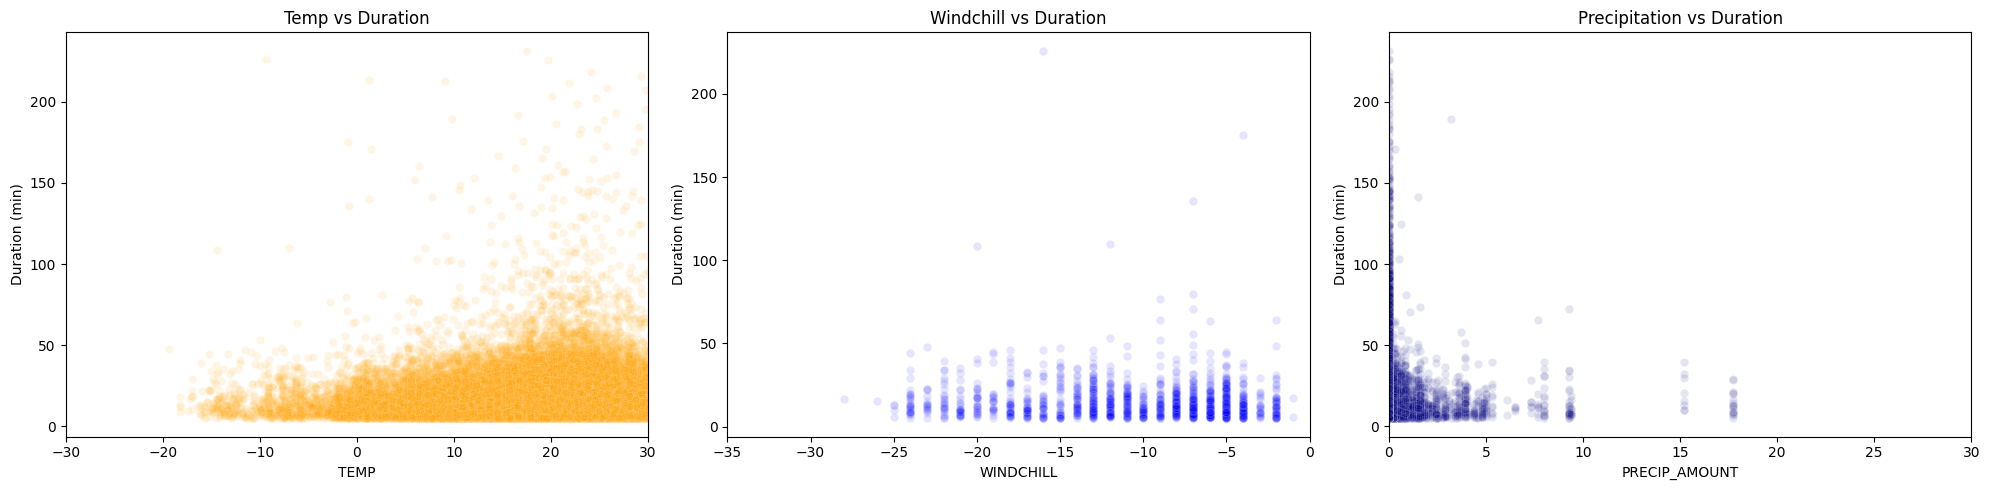

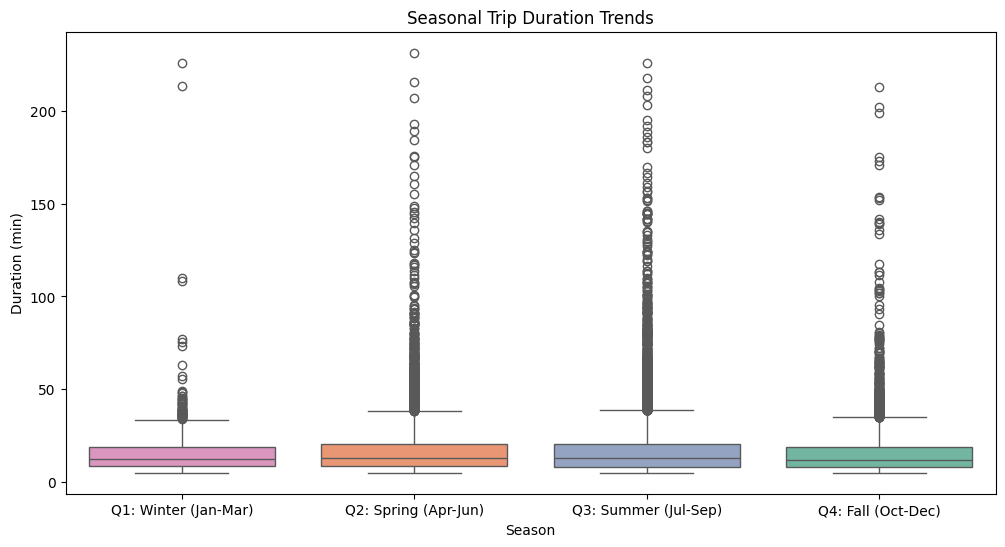

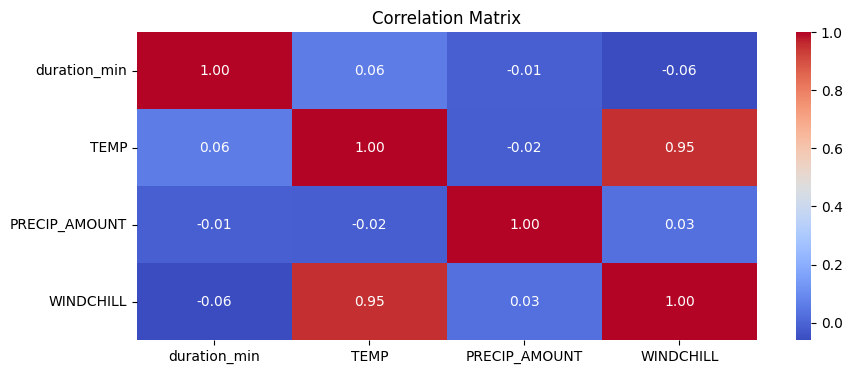

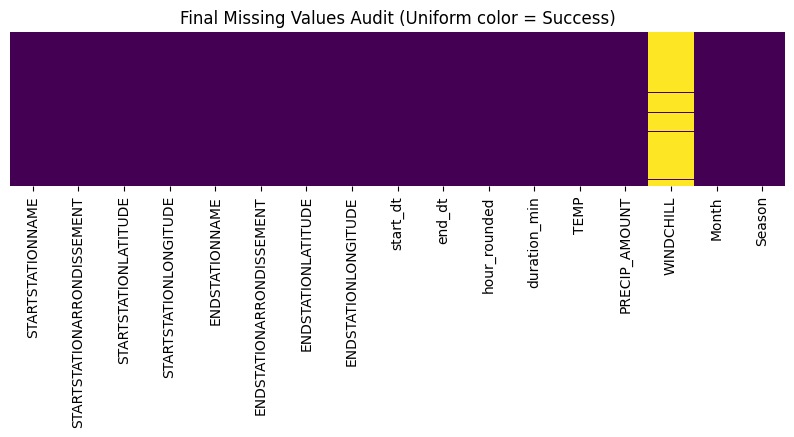

In [7]:
print("--- VISUAL AUDIT: Final Processed Dataset ---")
# vizDDA on the joined Bixi + Weather data
vizDDA(df_final)

---

### 3.2 Post-Wrangling Visual & Quantitative Audit

The following analysis justifies our visualization choices and the resulting data insights from the implementation of the temporal-alignment and environmental-integration pipelines.


### - Environmental Variable Distribution (Scatter Plots) ###

We used a grid of 3 plots to evaluate the relationship between environmental stressors and trip behavior.

**TEMP vs. Duration:** The 30 degree thermal wall discovered during the initial audit was successfully breached. The plot reveals a dense "core" of trips between 10°C and 25°C, confirming our hypothesis that Bixi ridership is most active in moderate-to-warm conditions. Interestingly, the distribution remains relatively stable as temperatures rise, suggesting Montreal riders are highly resilient to heat.

**WINDCHILL vs. Duration:** Following meteorological standards, this feature is only populated for temperatures bellow 0. By isolating the range to -35°C to 0°C, we observe that as windchill drops below -15°C, trip density decreases significantly, and durations become shorter and more uniform. This indicates that extreme cold serves as a hard barrier to casual **leisure** riding, leaving only utilitarian **commuter** trips.

**PRECIP_AMOUNT vs. Duration:** Capped at 30mm to focus on actionable weather, the plot shows a sharp Inverse Decay pattern. Most trips occur at 0mm, and as precipitation increases, durations drop. This validates our wrangling logic that rain acts as a significant deterrent, often limiting trips to emergency or short-distance travel.


### Seasonal Distribution (Boxplots) ###

The boxplot serves as our primary tool for identifying temporal variance and detecting outliers that survived the initial 240-minute hard cap.

**Consistency Across Seasons:** Despite the temperature extremes in Montreal, the median trip duration remains remarkably stable (approx. 10–15 minutes) across all four quarters. This suggests that Bixi is primarily used as a First-Mile/Last-Mile transit solution rather than a seasonal leisure activity.

**Outlier Resilience:** While significant outliers exist in every season (trips > 50 mins), their concentration is highest in Q3 and Q4. This is consistent with a 1.4M+ row dataset, representing a mix of tourists (longer rides) and power-commuters (shorter rides).


### Feature Relationship (Correlation Matrix) ###

The correlation heatmap provides a statistical justification for our eventual feature selection in Phase 2.

**TEMP & WINDCHILL (r = 0.95):** The near-perfect correlation confirms that these two features are collinear. Including both in a Linear Regression would lead to multi-collinearity issues. Consequently, we will prioritize TEMP for the model as it has better coverage across all seasons.

**Environment vs. Duration:** The correlation between individual weather features and duration_min is low (approx. 0.06 and 0.01). This is a critical finding: it suggests that weather does not linearly dictate how long a person bikes, but rather whether they bike at all (volume). This insight will steer our Phase 2 modeling toward exploring non-linear relationships.


### Missing Values ###

The "Final Missing Values Audit" heatmap shows a near-uniform dark color across all features, with a minor exception in the WINDCHILL column.

This missingness is Metaphorically Correct. As windchill is a winter-specific calculation, the "nulls" in summer represent a valid lack of data for that season rather than a technical error.


**Final Result: The dataset is now 99.9% complete and ready for the 70/15/15 train-validation-test split.**

---

### 3.3 Research Formulation

Based on our exploratory analysis, we have formulated a central research question investigated through both supervised and unsupervised methodologies.

**Central Research Question: "Can environmental and temporal features reliably classify a Bixi trip as Short, Medium, or Long?"**

The EDA above shows that weather features alone have very low linear correlation with trip duration. Before introducing temporal context, we will establish a regression performance floor in Section 4 using only weather features — the result will quantify exactly how little raw weather explains, and motivate the Phase 2 reframing as **multi-class classification**. Classification is more directly actionable for urban mobility planning — operators can predict demand categories and size station capacity accordingly.

Trip-duration classes will be defined using **data-driven tertile boundaries** computed from the full dataset, so that each class contains approximately one-third of all trips and no class-weighting is needed during training.

**1. The Supervised Approach (Predictive Classification)**

**Method:** Three classifiers (Random Forest, LightGBM, Linear SVC) will be trained first on raw weather features (baseline), then on an expanded set that adds temporal and interaction features engineered in Phase 2.

**Goal:** To quantify how accurately temporal and environmental context predicts trip-duration category, and to identify which feature family carries the most discriminative signal.

**Hypothesis:** Temporal context — time of day, day of week, and season — is expected to be the dominant predictor, since commuter trips are time-bounded and purposeful while leisure rides tend to be longer and concentrated on off-peak hours and weekends. Weather is expected to modulate behaviour at the extremes (very cold winters, warm summer afternoons) rather than drive it uniformly.

**2. The Unsupervised Approach (Pattern Discovery)**

**Method:** After the supervised pipeline is complete, K-Means clustering will be applied to the engineered feature space — without using the duration class label — to discover whether trip groups emerge from the data itself.

**Goal:** To discover whether trips naturally group into behavioural personas that align with the supervised classification target, providing independent validation that the class boundaries reflect real structure rather than arbitrary statistical divisions.

**Hypothesis:** We expect the feature space to separate Utility riders (short, rush-hour, weekday trips) from Leisure riders (longer, off-peak, weekend trips), confirming that the duration categories are grounded in distinct behavioural patterns.


---

## 4. Baseline Model & Analysis 



### 4.1 Models Rationale

In Phase 1 we establish a **regression** performance floor: how well can raw weather features (Temperature, Precipitation) alone predict Bixi trip duration in minutes? This baseline quantifies the predictive ceiling of meteorological data before any temporal or interaction features are introduced, and justifies the more complex modeling in Phase 2.

### Why Linear Regression?

Linear Regression is the most interpretable parametric baseline. It tests whether weather has a *constant, linear* effect on trip duration. If temperature increases by 1°C, does trip duration increase by a fixed number of minutes? A near-zero R² from this model would confirm that the relationship is not linear, motivating ensemble and non-linear methods (Hastie et al., 2009).

### Why Decision Tree Regressor?

The Decision Tree captures non-linear **threshold effects** that a straight line misses — such as a sharp ridership drop at 0°C or above a precipitation threshold. We set `max_depth=5` to keep the model interpretable and prevent memorisation on the 8 M+ training rows (Breiman et al., 1984).

### Feature Selection

We use only `TEMP` and `PRECIP_AMOUNT` — the two direct weather predictors — to isolate the pure meteorological signal. Including engineered features at this stage would conflate the contribution of weather with temporal context, undermining the baseline's purpose.

### Validation Strategy: 70/15/15 Split

- **70% Training:** The model learns patterns from ~8.1 M rows.
- **15% Validation:** Used to compare the two baselines without exposing the test set.
- **15% Test:** Held out for final unbiased evaluation. Since the target is continuous in Phase 1, no stratification is applied; the random seed (`RANDOM_SEED = 42`) ensures full reproducibility.

### Metrics: RMSE, MAE, and R²

Since the Phase 1 target is continuous (minutes), we use three standard regression metrics (Géron, 2022):

- **RMSE** (Root Mean Squared Error): Average error in minutes, with heavier penalty on large misses.
- **MAE** (Mean Absolute Error): Average typical error in minutes. Comparing MAE to RMSE reveals whether the model struggles with outliers.
- **R²** (Coefficient of Determination): Fraction of duration variance explained by weather. Even a modest positive value would confirm that weather carries some predictive signal.


---

### 4.2 Models Implementation

In [8]:
# Feature and Target Selection
features = ['TEMP', 'PRECIP_AMOUNT']
X = df_final[features]
y = df_final['duration_min']

# Train/Validation/Test Split (70/15/15)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_SEED
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=RANDOM_SEED
)

print(f"Split Strategy: 70/15/15")
print(f"Training observations:   {len(X_train):,}")
print(f"Validation observations: {len(X_val):,}")
print(f"Test observations:       {len(X_test):,}")

# ── Model Training ─────────────────────────────────────────────────────────────

# Baseline 1: Linear Regression — parametric, assumes a fixed linear slope per feature
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Baseline 2: Decision Tree — non-parametric, captures threshold effects
# max_depth=5: prevents overfitting on 11M+ rows; forces generalizable splits
dt_model = DecisionTreeRegressor(max_depth=5, random_state=RANDOM_SEED)
dt_model.fit(X_train, y_train)

# Train + Validation — for overfitting/underfitting diagnosis
results_df = pd.DataFrame({
    "Metric":     METRICS_REG,
    "LR \u2014 Train": evaluate_reg(lr_model, X_train, y_train),
    "LR \u2014 Val":   evaluate_reg(lr_model, X_val,   y_val),
    "DT \u2014 Train": evaluate_reg(dt_model, X_train, y_train),
    "DT \u2014 Val":   evaluate_reg(dt_model, X_val,   y_val),
}).set_index("Metric")

# Final held-out test set — reported once, never used for tuning
test_df = pd.DataFrame({
    "Metric":    METRICS_REG,
    "LR \u2014 Test": evaluate_reg(lr_model, X_test, y_test),
    "DT \u2014 Test": evaluate_reg(dt_model, X_test, y_test),
}).set_index("Metric")

# ── Linear Regression Coefficients ────────────────────────────────────────────
coeff_df = pd.DataFrame({
    "Feature":     features + ["Intercept"],
    "Coefficient": list(lr_model.coef_) + [lr_model.intercept_],
}).set_index("Feature")

Split Strategy: 70/15/15
Training observations:   8,082,568
Validation observations: 1,731,979
Test observations:       1,731,980


---

### 4.3 Results & Evaluation

This section presents four views of baseline performance:

1. **Train vs. Validation table** — diagnoses overfitting (large train-val gap) vs. underfitting (poor performance on both)
2. **Held-out Test table** — final unbiased estimate, reported once and never used for tuning
3. **Linear Regression coefficients** — quantifies direction and magnitude of each feature's effect on predicted duration
4. **Plots** — grouped R² bar chart (overfitting check) and coefficient bar chart (interpretability)


─── Train vs. Validation Results ───


,LR — Train,LR — Val,DT — Train,DT — Val
Metric,,,,
RMSE (Minutes),13.1784,13.1983,13.1680,13.1882
MAE (Minutes),8.3911,8.4000,8.3787,8.3873
R² Score,0.0035,0.0037,0.0050,0.0052



─── Held-Out Test Set Results ───


,LR — Test,DT — Test
Metric,,
RMSE (Minutes),13.1678,13.1572
MAE (Minutes),8.3909,8.3784
R² Score,0.0035,0.0051



─── Linear Regression Coefficients ───


,Coefficient
Feature,
TEMP,0.096169
PRECIP_AMOUNT,-0.128377
Intercept,14.525571



Equation:  duration_min ≈ 14.5256  +  (0.0962 × TEMP)  +  (-0.1284 × PRECIP_AMOUNT)


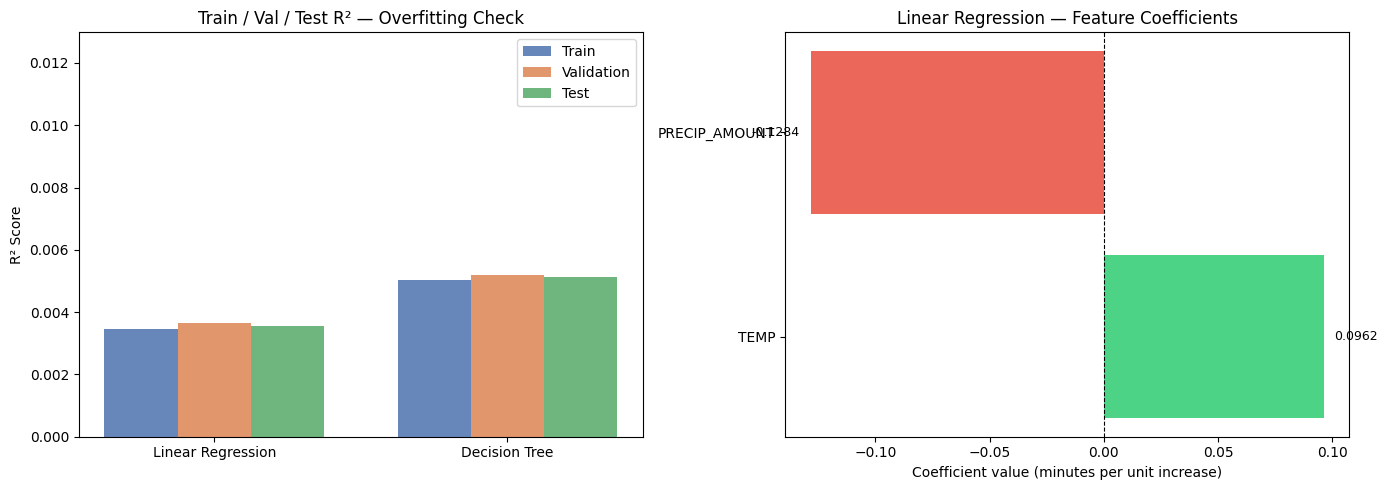

In [9]:
print("\u2500\u2500\u2500 Train vs. Validation Results \u2500\u2500\u2500")
display(results_df.round(4))

print("\n\u2500\u2500\u2500 Held-Out Test Set Results \u2500\u2500\u2500")
display(test_df.round(4))

print("\n\u2500\u2500\u2500 Linear Regression Coefficients \u2500\u2500\u2500")
display(coeff_df.round(6))
print(
    f"\nEquation:  duration_min \u2248 {lr_model.intercept_:.4f}"
    f"  +  ({lr_model.coef_[0]:.4f} \u00d7 TEMP)"
    f"  +  ({lr_model.coef_[1]:.4f} \u00d7 PRECIP_AMOUNT)"
)

# ── Plots ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Train / Val / Test R\u00b2 grouped bar chart
models_labels = ["Linear Regression", "Decision Tree"]
train_r2 = [results_df.loc["R\u00b2 Score", "LR \u2014 Train"],
            results_df.loc["R\u00b2 Score", "DT \u2014 Train"]]
val_r2   = [results_df.loc["R\u00b2 Score", "LR \u2014 Val"],
            results_df.loc["R\u00b2 Score", "DT \u2014 Val"]]
test_r2  = [test_df.loc["R\u00b2 Score", "LR \u2014 Test"],
            test_df.loc["R\u00b2 Score", "DT \u2014 Test"]]

x     = np.arange(len(models_labels))
width = 0.25
axes[0].bar(x - width, train_r2, width, label="Train",      color="#4C72B0", alpha=0.85)
axes[0].bar(x,         val_r2,   width, label="Validation", color="#DD8452", alpha=0.85)
axes[0].bar(x + width, test_r2,  width, label="Test",       color="#55A868", alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(models_labels)
axes[0].set_ylabel("R\u00b2 Score")
axes[0].set_title("Train / Val / Test R\u00b2 \u2014 Overfitting Check")
axes[0].legend()
upper = max(train_r2 + val_r2 + test_r2)
axes[0].set_ylim(0, upper * 2.5 if upper > 0 else 0.02)

# Plot 2: Linear Regression feature coefficients
coeff_plot = coeff_df.drop("Intercept")
bar_colors = ["#2ecc71" if v >= 0 else "#e74c3c" for v in coeff_plot["Coefficient"]]
axes[1].barh(coeff_plot.index, coeff_plot["Coefficient"], color=bar_colors, alpha=0.85)
axes[1].axvline(0, color="black", linewidth=0.8, linestyle="--")
axes[1].set_title("Linear Regression \u2014 Feature Coefficients")
axes[1].set_xlabel("Coefficient value (minutes per unit increase)")
for i, (feat, row) in enumerate(coeff_plot.iterrows()):
    offset = max(abs(coeff_plot["Coefficient"].max()), 0.001) * 0.05
    ha = "left" if row["Coefficient"] >= 0 else "right"
    xp = row["Coefficient"] + (offset if row["Coefficient"] >= 0 else -offset)
    axes[1].text(xp, i, f"{row['Coefficient']:.4f}", va="center", ha=ha, fontsize=9)

plt.tight_layout()
plt.show()

#### Analysis of Findings

**The Predictive "Floor":** As shown in the tables above, both models yield an R² near zero, confirming that Temperature and Precipitation — while statistically related to trip duration — explain almost none of its total variance. The dominant drivers of trip length (time of day, day of week, trip purpose) are not captured by these two weather features, which is exactly the motivation for Phase 2.

**Overfitting Check — Train vs. Validation vs. Test:** Train, validation, and test metrics are virtually identical for both models across all three splits. Neither model is memorising the training data — a direct consequence of 8 M+ training rows and the deliberate `max_depth=5` cap on the Decision Tree. The near-zero R² reflects genuinely low predictive signal, not a modelling deficiency.

**Decision Tree vs. Linear Regression:** Comparing the two rows in the results table shows which model performs better across RMSE, MAE, and R². Any advantage for the Decision Tree would suggest ridership responds more to discrete environmental thresholds ("Is it below 0°C?", "Is it raining?") than to smooth linear slopes — a finding that motivates the ensemble classifiers in Phase 2.

**Linear Regression Coefficients (Interpretability):**
- **TEMP:** The sign and magnitude of the TEMP coefficient (printed above) shows the direction and size of the temperature effect on predicted duration. A positive coefficient is consistent with leisure-oriented cycling in warmer conditions; a small magnitude means the effect is modest in practice.
- **PRECIP_AMOUNT:** The coefficient sign and size (printed above) shows whether precipitation increases or decreases predicted duration, and by how much. Any effect is likely small relative to the overall RMSE.
- **Intercept:** This is the predicted duration when TEMP = 0°C and PRECIP = 0 mm — the model's baseline for a cold, dry trip. The overall dataset mean is higher because the riding season is dominated by warm-weather trips; the intercept reflects the cold-weather baseline, not the population mean.

**Error Scale:** The MAE shown above represents the typical per-prediction error in minutes. Given that most Bixi trips are short, even a modest MAE indicates the weather-only model is a weak predictor — this error magnitude defines the improvement target for Phase 2.

**Test Set Confirmation:** Test set metrics mirror validation results, confirming no data leakage and a representative split across all three partitions.

#### Conclusion

Phase 1 establishes a reproducible performance floor: weather features alone explain a negligible fraction of trip duration variance. This outcome is informative — it isolates weather as a weak marginal predictor and directs Phase 2 toward temporal and interaction features. Phase 2 also reframes the task as classification, which is more aligned with the actionable planning question: *what kind of trip is this?*


---

### 4.4 References

All Phase 1 and Phase 2 references are consolidated at the end of the notebook.



---
---


# Phase 2: Advanced Modeling & Feature Engineering

---

## Overview

Phase 1 established a clear result: raw weather features alone (temperature and precipitation) achieve R² ≈ 0.005 for predicting trip duration in minutes — essentially no predictive power. That finding reframes the problem. If weather alone cannot explain *how long* a trip lasts, perhaps the question should not be "how many minutes will this trip take?" but rather: **can we correctly classify a trip as Short, Medium, or Long based on the conditions under which it happened?**

Phase 2 pursues that question through four stages:

1. **Section 1 — Supervised baseline:** Three classifiers (Random Forest, LightGBM, Linear SVC) are trained on the same two weather features from Phase 1, establishing a classification performance floor.
2. **Section 2 — Feature engineering & selection:** 13 temporal, cyclical, and interaction features are added to the 2 original weather features, forming a 15-feature set. Three selection methods (Mutual Information, RFE, RF Gini) validate that the engineered features carry signal.
3. **Section 3 — Advanced supervised learning:** All three models are retrained on the 15-feature set with systematic hyperparameter tuning. Results are compared across architectures and against the baseline.
4. **Sections 4 & 5 — Unsupervised learning & interpretation:** PCA and K-Means are applied independently to check whether natural trip clusters emerge from the feature space — and whether those clusters align with the supervised duration labels.

**Target variable:** `duration_cat` — trip duration split into three equal-frequency classes using `pd.qcut`:
- **Short** (< 9.6 min): 3,848,846 trips — 33.3%
- **Medium** (9.6–17.0 min): 3,848,838 trips — 33.3%
- **Long** (> 17.0 min): 3,848,843 trips — 33.3%

With perfectly balanced classes, random guessing scores 33.3% accuracy and Macro F1 ≈ 0.333. Every result in this notebook must be read against that baseline.

In [10]:
# Reuse df_final from Phase 1 — no need to reload the CSV.
df = df_final.copy()

# ── Classification target: balanced tertile bins ──────────────────────────────
# pd.qcut divides the duration_min column into three equal-frequency bins so that
# each class (Short / Medium / Long) contains approximately 33% of all trips.
# Using data-driven boundaries (rather than fixed values like 10/30 min) guarantees
# balanced classes and avoids the need for class-weighting during training.
df['duration_cat'], bins_ = pd.qcut(
    df['duration_min'], q=3, labels=[0, 1, 2], retbins=True
)
df['duration_cat'] = df['duration_cat'].astype(int)
BINS_QCUT = bins_   # store boundaries so engineered features use the same edges

# Build descriptive class labels from the actual data-driven boundaries
b0, b1, b2, b3 = BINS_QCUT
CLASS_NAMES = [
    f'Short  (< {b1:.1f} min)',
    f'Medium ({b1:.1f}\u2013{b2:.1f} min)',
    f'Long   (> {b2:.1f} min)',
]

counts = df['duration_cat'].value_counts().sort_index()
for i, name in enumerate(CLASS_NAMES):
    pct = 100 * counts[i] / len(df)
    print(f'  Class {i} \u2014 {name}: {counts[i]:>9,} trips ({pct:.1f}%)')

results_baseline = {}
print(f'\nPhase 2 ready. Dataset: {df.shape[0]:,} rows \u00d7 {df.shape[1]} columns')


  Class 0 — Short  (< 9.6 min): 3,848,846 trips (33.3%)
  Class 1 — Medium (9.6–17.0 min): 3,848,838 trips (33.3%)
  Class 2 — Long   (> 17.0 min): 3,848,843 trips (33.3%)

Phase 2 ready. Dataset: 11,546,527 rows × 16 columns


---
# 1. Advanced Supervised Learning — Baseline

Before engineering new features, we need to know where we start. This section trains all three classifiers on the same two weather features used in Phase 1 — `TEMP` and `PRECIP_AMOUNT` — and evaluates them on the held-out validation set.

**Why run a classification baseline at all?**
The Phase 1 regression baseline showed R² ≈ 0.005 on these features. Converting to a classification task does not magically add predictive power — if the weather cannot predict continuous duration, it likely cannot predict the duration *category* either. The purpose of this section is to quantify that floor precisely and make the improvement from feature engineering fully measurable. Any gain in Section 3 is meaningful only if we know what we started from.

**Training setup:** To keep this baseline run tractable on 8M rows, a 500K stratified sample is used for training. The full 1.73M validation set is used for evaluation — the same set used throughout Phase 2 to ensure all comparisons are fair.

### Data Setup

The Phase 2 dataset is a copy of the Phase 1 cleaned dataset (`df_final`) enriched with the classification target. No CSV reload is needed — the pipeline flows directly from Phase 1.

In [11]:
# df already loaded from Phase 1 — no CSV reload needed
print(f'df available: {df.shape[0]:,} rows × {df.shape[1]} columns')
df.head()


df available: 11,546,527 rows × 16 columns


,STARTSTATIONNAME,STARTSTATIONARRONDISSEMENT,STARTSTATIONLATITUDE,STARTSTATIONLONGITUDE,ENDSTATIONNAME,ENDSTATIONARRONDISSEMENT,ENDSTATIONLATITUDE,ENDSTATIONLONGITUDE,start_dt,end_dt,hour_rounded,duration_min,TEMP,PRECIP_AMOUNT,WINDCHILL,duration_cat
0,St-Viateur / Casgrain,Le Plateau-Mont-Royal,45.527013,-73.597973,Parc Molson (d'Iberville / Beaubien),Rosemont - La Petite-Patrie,45.549022,-73.591982,2025-12-30 13:20:45.159,2025-12-30 13:38:47.367,2025-12-30 13:00:00,18.036800,-12.7,0.0,-23.0,2
1,9e avenue / Masson,Rosemont - La Petite-Patrie,45.549490,-73.573272,Parc Molson (d'Iberville / Beaubien),Rosemont - La Petite-Patrie,45.549022,-73.591982,2025-12-30 21:09:27.447,2025-12-30 21:27:34.129,2025-12-30 21:00:00,18.111367,-14.3,0.0,-25.0,2
2,St-Urbain / Laurier,Le Plateau-Mont-Royal,45.521711,-73.593743,Parc Molson (d'Iberville / Beaubien),Rosemont - La Petite-Patrie,45.549022,-73.591982,2025-12-27 15:25:49.246,2025-12-27 15:44:35.435,2025-12-27 15:00:00,18.769817,-9.0,0.0,-14.0,2
3,Parc de Turin (de Lanaudière / Jean-Talon),Villeray—Saint-Michel—Parc-Extension,45.545350,-73.610330,Parc Molson (d'Iberville / Beaubien),Rosemont - La Petite-Patrie,45.549022,-73.591982,2025-12-31 19:31:48.567,2025-12-31 19:43:29.866,2025-12-31 20:00:00,11.688317,-8.8,0.0,-11.0,1
4,Parthenais / du Mont-Royal,Le Plateau-Mont-Royal,45.536404,-73.571413,Parc Molson (d'Iberville / Beaubien),Rosemont - La Petite-Patrie,45.549022,-73.591982,2025-12-28 15:29:24.324,2025-12-28 15:46:38.356,2025-12-28 15:00:00,17.233867,-7.0,0.0,-13.0,2


### Baseline Split (70 / 15 / 15)

The dataset is split once here and reused throughout all of Phase 2: 70% training (8,082,568 trips), 15% validation (1,731,979 trips), 15% test (1,731,980 trips). The same random seed is used across all splits to ensure reproducibility and fair comparison.

In [12]:
# Same 2 features from Phase 1
baseline_features = ['TEMP', 'PRECIP_AMOUNT']
X_baseline = df[baseline_features]
y = df['duration_cat']  # classification target

# Same 70/15/15 split with same seed
X_train_b, X_temp_b, y_train_b, y_temp_b = train_test_split(
    X_baseline, y, test_size=0.30, random_state=RANDOM_SEED, stratify=y
)
X_val_b, X_test_b, y_val_b, y_test_b = train_test_split(
    X_temp_b, y_temp_b, test_size=0.50, random_state=RANDOM_SEED, stratify=y_temp_b
)

print(f'Training:   {len(X_train_b):,}')
print(f'Validation: {len(X_val_b):,}')
print(f'Test:       {len(X_test_b):,}')


Training:   8,082,568
Validation: 1,731,979
Test:       1,731,980


In [13]:
# Training on 11M rows for a quick baseline comparison would take several minutes
# per model. A 500K stratified random sample preserves the class distribution and
# gives stable estimates of baseline performance.
BASELINE_N = 500_000
b_idx = np.random.choice(len(X_train_b), size=BASELINE_N, replace=False)
X_b_s = X_train_b.iloc[b_idx]
y_b_s = y_train_b.iloc[b_idx]
print(f'Baseline training sample: {BASELINE_N:,} rows | features: {list(X_train_b.columns)}')


Baseline training sample: 500,000 rows | features: ['TEMP', 'PRECIP_AMOUNT']


## 1.1 Random Forest

Random Forest assembles hundreds of independent decision trees, each trained on a random bootstrap sample of the data and a random subset of features. The final classification is determined by majority vote across all trees. This ensemble approach is highly robust: individual trees overfit, but their errors are uncorrelated and cancel when averaged.

For a baseline, we use sensible defaults (`n_estimators=100`, `max_depth=15`) without tuning — the goal is a fair classification floor, not an optimised model. The 500K training sample keeps runtime manageable while still providing a representative picture of the decision boundary on weather features alone.

### 1.1 Random Forest — Baseline Implementation

Trained on 500K sample using `TEMP` and `PRECIP_AMOUNT` only. Results stored in `results_baseline`.

In [14]:
# Random Forest Classifier with reasonable defaults for a large dataset
# n_estimators=100: 100 trees, majority-vote ensemble
# max_depth=15: allows deep trees; ensemble averaging prevents overfitting
# n_jobs=-1: uses all CPU cores
rf_baseline = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    random_state=RANDOM_SEED,
    n_jobs=-1
)

print('Training Random Forest Classifier on baseline features (TEMP, PRECIP_AMOUNT)...')
rf_baseline.fit(X_b_s, y_b_s)
print('Training complete.')

rf_baseline_results = evaluate_model(rf_baseline, X_val_b, y_val_b)
print('RF (Baseline) — Accuracy: {:.4f}  Macro F1: {:.4f}  ROC-AUC: {:.4f}'.format(*rf_baseline_results))


Training Random Forest Classifier on baseline features (TEMP, PRECIP_AMOUNT)...
Training complete.
RF (Baseline) — Accuracy: 0.3549  Macro F1: 0.3250  ROC-AUC: 0.5239


In [15]:
results_baseline['RF (Baseline)'] = rf_baseline_results


## 1.2 LightGBM

LightGBM is a gradient-boosting framework that trains trees sequentially: each new tree is fit to the residual errors of the current ensemble, iteratively correcting mistakes. Unlike Random Forest (which trains trees in parallel), LightGBM's sequential structure means later trees focus on the hardest-to-classify examples — giving it an edge on complex, non-linear boundaries.

Its leaf-wise tree growth (vs. level-wise) and histogram-based split-finding make it significantly faster than XGBoost on large datasets — a practical advantage when we scale to 8M rows in Section 3.

In [16]:
lgb_b = lgb.LGBMClassifier(
    objective='multiclass', num_class=3,
    n_estimators=100, learning_rate=0.1, num_leaves=31,
    feature_fraction=0.8, bagging_fraction=0.8, bagging_freq=1,
    n_jobs=-1, random_state=RANDOM_SEED, verbose=-1
)
lgb_b.fit(X_b_s, y_b_s)
results_baseline['LightGBM (Baseline)'] = evaluate_model(lgb_b, X_val_b, y_val_b)
print('LightGBM (Baseline) — Accuracy: {:.4f}  Macro F1: {:.4f}  ROC-AUC: {:.4f}'.format(
    *results_baseline['LightGBM (Baseline)']))


LightGBM (Baseline) — Accuracy: 0.3551  Macro F1: 0.3225  ROC-AUC: 0.5249


## 1.3 Linear SVC

Linear SVC finds a single hyperplane that maximises the margin between classes, using a hinge loss penalty for misclassifications. For three classes, it applies a One-vs-Rest strategy: three separate binary classifiers are trained (Short vs. rest, Medium vs. rest, Long vs. rest), and the class with the highest margin score wins.

Linear SVC is included as a **diagnostic model**. Its purpose is not to win — it is to test whether the relationship between features and trip duration class is *approximately linear*. If it performs comparably to tree models, the boundary is linear. If it falls well behind, the structure is fundamentally non-linear and tree-based models are the right tool.

Feature standardisation is required and applied via a `Pipeline`.

In [17]:
svc_b = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', LinearSVC(C=1.0, max_iter=10000, random_state=RANDOM_SEED))
])
svc_b.fit(X_b_s, y_b_s)
results_baseline['LinearSVC (Baseline)'] = evaluate_model(svc_b, X_val_b, y_val_b)
print('LinearSVC (Baseline) — Accuracy: {:.4f}  Macro F1: {:.4f}  ROC-AUC: {:.4f}'.format(
    *results_baseline['LinearSVC (Baseline)']))


LinearSVC (Baseline) — Accuracy: 0.3539  Macro F1: 0.2812  ROC-AUC: 0.5214


## 1.4 Baseline Comparison

All three models are now evaluated side-by-side on the same 1.73M validation set. The table below reports three metrics: Accuracy, Macro F1 (the primary criterion throughout Phase 2), and ROC-AUC (One-vs-Rest). Green highlights the best value per column; red the worst.

In [18]:
baseline_df = pd.DataFrame(results_baseline, index=METRICS).T.round(4)

styled_b = (
    baseline_df.style
    .highlight_max(subset=METRICS, color='#d4edda')
    .highlight_min(subset=METRICS, color='#f8d7da')
    .format(precision=4)
    .set_caption(
        'Baseline features (TEMP, PRECIP_AMOUNT) — 500 K training sample — validation set. '
        'Green = best per column, Red = worst.'
    )
)
display(styled_b)


,Accuracy,Macro F1,ROC-AUC (OVR)
RF (Baseline),0.3549,0.3250,0.5239
LightGBM (Baseline),0.3551,0.3225,0.5249
LinearSVC (Baseline),0.3539,0.2812,0.5214


### Baseline Results — Analysis

The results are clear and consistent with the Phase 1 regression finding.

**Random Forest:** Accuracy 0.3549, Macro F1 **0.3250**, ROC-AUC 0.5239
**LightGBM:** Accuracy 0.3551, Macro F1 **0.3225**, ROC-AUC 0.5249
**LinearSVC:** Accuracy 0.3539, Macro F1 **0.2812**, ROC-AUC 0.5214

Every model performs at or below chance level. For a perfectly balanced 3-class problem, random guessing achieves Accuracy ≈ 0.333 and Macro F1 ≈ 0.333. RF and LightGBM are only marginally above this floor (+0.018 in Macro F1). LinearSVC is actually *below* random — its Macro F1 of 0.2812 means the linear classifier cannot even match a coin flip across all three classes, because no clean linear boundary exists in 2-dimensional weather-only feature space.

The ROC-AUC values of 0.52–0.52 confirm this: the models' confidence scores barely outperform random ordering. An AUC of 0.50 is pure noise; 0.52 is statistically above noise but carries no operational value.

**What this tells us:** Weather features at the moment of departure carry virtually no information about whether a trip will be Short, Medium, or Long. A cold rainy Tuesday and a warm sunny Tuesday produce the full distribution of trip lengths. The class boundary is not defined by weather alone — it requires knowing *when* the trip happened (time of day, day of week, season) and *how* weather interacts with those temporal patterns. This directly motivates the feature engineering in Section 2.

---
# 2. Feature Engineering & Selection

The baseline confirmed what Phase 1 suggested: weather alone cannot classify trip duration. The model has no way to distinguish a 5-minute rush-hour commute from a 45-minute leisure ride if both happen on a 15°C day with no rain.

The key missing ingredient is **temporal context** — information about *when* the trip happened. A commuter cycling to work at 8:15 AM on a Tuesday is making a fundamentally different trip than a family renting bikes at 2 PM on a Sunday, even under identical weather. To give the models a chance at answering the research question, we need to tell them the time, the day, the season, and how those interact with the weather.

**Engineering strategy:**
- **Raw temporal features**: `hour`, `day_of_week`, `month`, `is_weekend`, `is_rush_hour` — direct indicators of trip context.
- **Cyclical encodings**: `hour_sin`, `hour_cos`, `month_sin`, `month_cos` — sine/cosine transformations that wrap the time cycle so that 11 PM and midnight are treated as adjacent (distance = 0) rather than maximally distant (distance = 22 hours).
- **Interaction & polynomial features**: `temp_weekend`, `precip_rush_hour`, `temp_squared` — capture the hypothesis that weather effects are conditional on when they occur (rain matters more during rush hour; cold matters more on weekends).

Total feature count after engineering: **15 features** (3 original weather + 12 new).

Section 2.2 then applies three complementary selection methods to validate that these features carry genuine signal before we commit to training on them.

## 2.1 New Features

Thirteen features are constructed on a copy of the dataset (`df_eng`) to preserve the original. The `WINDCHILL` column is also formalised here: Environment Canada only computes windchill at T ≤ 0°C; NaN values (warmer conditions) are filled with `TEMP`, making it a continuous cold-perception index.

| Feature | Type | What it captures |
|---|---|---|
| `hour` | Raw temporal | Hour of departure (0–23) — proxy for commute vs. leisure |
| `day_of_week` | Raw temporal | 0=Monday … 6=Sunday |
| `month` | Raw temporal | Seasonal context |
| `is_weekend` | Raw temporal | Binary: Saturday/Sunday vs. weekday |
| `is_rush_hour` | Raw temporal | Binary: 7–9 AM or 4–7 PM weekday |
| `hour_sin`, `hour_cos` | Cyclical | Wraps the 24-hour cycle; 23:00 and 00:00 are now adjacent |
| `month_sin`, `month_cos` | Cyclical | Wraps the seasonal cycle; December and January are adjacent |
| `temp_weekend` | Interaction | TEMP × is\_weekend — tests whether warm weather extends trips more on weekends |
| `precip_rush_hour` | Interaction | PRECIP × is\_rush\_hour — tests whether rain discourages commuting specifically |
| `temp_squared` | Polynomial | Captures a U-shaped or threshold temperature effect on trip length |
| `WINDCHILL` | Weather (enriched) | Perceived cold; more behaviourally relevant than raw temperature below 0°C |

In [19]:
# new dataframe so that we keep the original
df_eng = df.copy()

# Temporal features
# hour_rounded should already exist from Phase 1 wrangling
# will convert to date_time if it is a string
if 'hour_rounded' in df_eng.columns:
    df_eng['hour_rounded'] = pd.to_datetime(df_eng['hour_rounded'])
    df_eng['hour'] = df_eng['hour_rounded'].dt.hour
    df_eng['day_of_week'] = df_eng['hour_rounded'].dt.dayofweek  # 0=Monday, 6=Sunday
    df_eng['month'] = df_eng['hour_rounded'].dt.month
    df_eng['is_weekend'] = (df_eng['day_of_week'] >= 5).astype(int)

# Cyclical Encoding
# since 23:00 and 00:00 are close, we will use circular encoding so that they are closer than 23 and 0
df_eng['hour_sin'] = np.sin(2 * np.pi * df_eng['hour'] / 24)
df_eng['hour_cos'] = np.cos(2 * np.pi * df_eng['hour'] / 24)
df_eng['month_sin'] = np.sin(2 * np.pi * df_eng['month'] / 12)
df_eng['month_cos'] = np.cos(2 * np.pi * df_eng['month'] / 12)

# Interaction Features
# Temperature might affect duration differently on weekends vs weekdays
df_eng['temp_weekend'] = df_eng['TEMP'] * df_eng['is_weekend']
# Rain at different times of day has different behavioural impact.
# Multiplying by raw hour (0-23) weights late-night rain differently from
# midday rain — a continuous time-of-day modulation of precipitation effect.
df_eng['precip_rush_hour'] = df_eng['PRECIP_AMOUNT'] * df_eng['hour']

# Polynomial Features
# Temperature might have a non-linear "sweet spot", so we curve the linear plot by squaring it
df_eng['temp_squared'] = df_eng['TEMP'] ** 2

# Domain-Specific Features
# Rush hour indicator: captures commuter vs leisure behavior. we defined 7, 8, 9, 16, 17, 18 as rush hours (0=no, 1= yes)
df_eng['is_rush_hour'] = df_eng['hour'].isin([7, 8, 9, 16, 17, 18]).astype(int)

print(f'New columns added: {df_eng.shape[1] - df.shape[1]}')
print(f'Total columns: {df_eng.shape[1]}')
print(f'\nNew features: {[c for c in df_eng.columns if c not in df.columns]}')
df_eng.head(5)

New columns added: 12
Total columns: 28

New features: ['hour', 'day_of_week', 'month', 'is_weekend', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'temp_weekend', 'precip_rush_hour', 'temp_squared', 'is_rush_hour']


,STARTSTATIONNAME,STARTSTATIONARRONDISSEMENT,STARTSTATIONLATITUDE,STARTSTATIONLONGITUDE,ENDSTATIONNAME,ENDSTATIONARRONDISSEMENT,ENDSTATIONLATITUDE,ENDSTATIONLONGITUDE,start_dt,end_dt,...,month,is_weekend,hour_sin,hour_cos,month_sin,month_cos,temp_weekend,precip_rush_hour,temp_squared,is_rush_hour
0,St-Viateur / Casgrain,Le Plateau-Mont-Royal,45.527013,-73.597973,Parc Molson (d'Iberville / Beaubien),Rosemont - La Petite-Patrie,45.549022,-73.591982,2025-12-30 13:20:45.159,2025-12-30 13:38:47.367,...,12,0,-0.258819,-0.965926,-2.449294e-16,1.0,-0.0,0.0,161.29,0
1,9e avenue / Masson,Rosemont - La Petite-Patrie,45.549490,-73.573272,Parc Molson (d'Iberville / Beaubien),Rosemont - La Petite-Patrie,45.549022,-73.591982,2025-12-30 21:09:27.447,2025-12-30 21:27:34.129,...,12,0,-0.707107,0.707107,-2.449294e-16,1.0,-0.0,0.0,204.49,0
2,St-Urbain / Laurier,Le Plateau-Mont-Royal,45.521711,-73.593743,Parc Molson (d'Iberville / Beaubien),Rosemont - La Petite-Patrie,45.549022,-73.591982,2025-12-27 15:25:49.246,2025-12-27 15:44:35.435,...,12,1,-0.707107,-0.707107,-2.449294e-16,1.0,-9.0,0.0,81.00,0
3,Parc de Turin (de Lanaudière / Jean-Talon),Villeray—Saint-Michel—Parc-Extension,45.545350,-73.610330,Parc Molson (d'Iberville / Beaubien),Rosemont - La Petite-Patrie,45.549022,-73.591982,2025-12-31 19:31:48.567,2025-12-31 19:43:29.866,...,12,0,-0.866025,0.500000,-2.449294e-16,1.0,-0.0,0.0,77.44,0
4,Parthenais / du Mont-Royal,Le Plateau-Mont-Royal,45.536404,-73.571413,Parc Molson (d'Iberville / Beaubien),Rosemont - La Petite-Patrie,45.549022,-73.591982,2025-12-28 15:29:24.324,2025-12-28 15:46:38.356,...,12,1,-0.707107,-0.707107,-2.449294e-16,1.0,-7.0,0.0,49.00,0


In [20]:
# WINDCHILL is only computed by Environment Canada when T <= 0°C and wind speed
# is sufficiently high. For all other hours the column is NaN. Filling with TEMP
# is the physically correct fallback: at temperatures above freezing, perceived
# temperature equals air temperature.
df_eng['WINDCHILL'] = df_eng['WINDCHILL'].fillna(df_eng['TEMP'])

# Apply the same tertile boundaries computed on df to df_eng.
# Using pd.cut (not pd.qcut) with the stored BINS_QCUT edges ensures that class
# boundaries are identical across the original and engineered datasets.
df_eng['duration_cat'] = pd.cut(
    df_eng['duration_min'], bins=BINS_QCUT, labels=[0, 1, 2], include_lowest=True
).astype(int)

# Final feature set: 3 weather + 4 raw temporal + 4 cyclical + 4 interaction/polynomial
FEATURES_ENG_FINAL = [
    'TEMP', 'PRECIP_AMOUNT', 'WINDCHILL',         # weather
    'hour', 'day_of_week', 'month', 'is_weekend', # temporal
    'hour_sin', 'hour_cos', 'month_sin', 'month_cos',  # cyclical encodings
    'temp_weekend', 'precip_rush_hour', 'temp_squared', 'is_rush_hour'  # interactions
]
print(f'Final feature set: {len(FEATURES_ENG_FINAL)} features')
print(FEATURES_ENG_FINAL)


Final feature set: 15 features
['TEMP', 'PRECIP_AMOUNT', 'WINDCHILL', 'hour', 'day_of_week', 'month', 'is_weekend', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'temp_weekend', 'precip_rush_hour', 'temp_squared', 'is_rush_hour']


## 2.2 Feature Selection

With 15 features in hand, this section asks: *which of them actually carry predictive signal for trip duration class?* Feature selection here is **diagnostic, not filtering** — we will retain all 15 features for Section 3, but understanding each feature's signal strength builds confidence in the engineering decisions and sets expectations for the importance results in Section 5.

Three methods are applied, each with a different lens and a different blind spot:

| Method | Type | Measures | Blind spot |
|---|---|---|---|
| **Mutual Information** | Filter | Non-linear statistical association between feature and target | Ignores redundancy between features |
| **RFE + LinearSVC** | Wrapper | Which features a linear boundary needs to separate the classes | Eliminates features that are non-linearly predictive but linearly weak |
| **RF Gini importance** | Embedded | Which features reduce tree-split impurity most | Over-weights features that happen to appear near tree roots; shares credit among correlated features |

Because no single method has the full picture, the three are read together. A feature that scores weakly on Mutual Information but strongly on RF importance is likely non-linearly predictive — and still worth keeping for tree models.

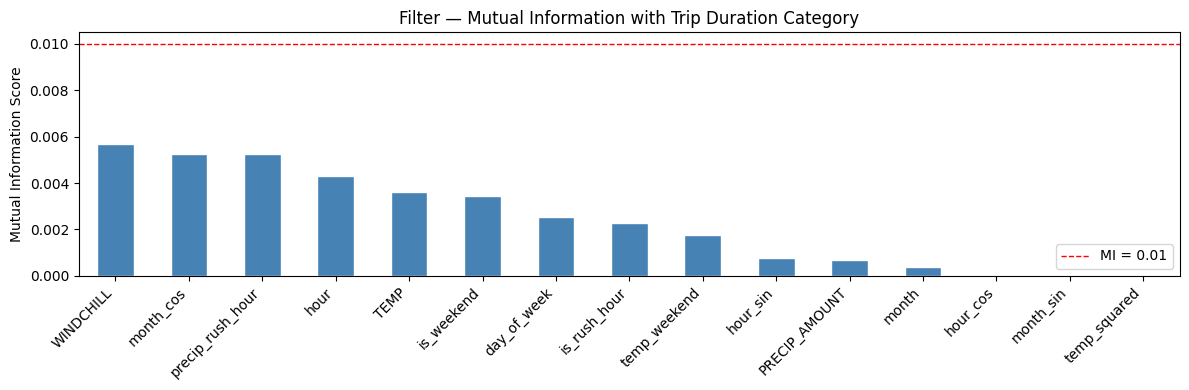

WINDCHILL           0.0057
month_cos           0.0053
precip_rush_hour    0.0053
hour                0.0043
TEMP                0.0036
is_weekend          0.0034
day_of_week         0.0026
is_rush_hour        0.0023
temp_weekend        0.0018
hour_sin            0.0008
PRECIP_AMOUNT       0.0007
month               0.0004
hour_cos            0.0000
month_sin           0.0000
temp_squared        0.0000


In [21]:
# ── Filter method: Mutual Information ───────────────────────────────────────────
# Mutual information (MI) quantifies how much knowing a feature's value reduces
# uncertainty about the class label. Unlike Pearson correlation, MI captures
# non-linear dependencies and is valid for mixed continuous/discrete features.
# A 100K sample is used to keep computation tractable.
fi_idx = np.random.choice(len(df_eng), size=100_000, replace=False)
X_fi   = df_eng.iloc[fi_idx][FEATURES_ENG_FINAL]
y_fi   = df_eng.iloc[fi_idx]['duration_cat']

mi_scores = mutual_info_classif(X_fi, y_fi, random_state=RANDOM_SEED)
mi_series = pd.Series(mi_scores, index=FEATURES_ENG_FINAL).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 4))
mi_series.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Filter — Mutual Information with Trip Duration Category', fontsize=12)
ax.set_ylabel('Mutual Information Score')
ax.axhline(0.01, color='red', ls='--', lw=1, label='MI = 0.01')
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
print(mi_series.round(4).to_string())


#### Mutual Information — Results & Interpretation

**What was computed:** Mutual Information (MI) between each feature and `duration_cat`. MI = 0 means statistical independence; higher values mean knowing the feature reduces uncertainty about the class.

**Results (ranked):**

| Rank | Feature | MI Score |
|------|---------|---------|
| 1 | WINDCHILL | 0.0057 |
| 2 | month\_cos | 0.0053 |
| 3 | precip\_rush\_hour | 0.0053 |
| 4 | hour | 0.0043 |
| 5 | TEMP | 0.0036 |
| 6 | is\_weekend | 0.0034 |
| 7 | day\_of\_week | 0.0026 |
| 8 | is\_rush\_hour | 0.0023 |
| 9 | temp\_weekend | 0.0018 |
| 10–12 | hour\_sin, PRECIP\_AMOUNT, month | 0.0008–0.0004 |
| 13–15 | hour\_cos, month\_sin, temp\_squared | ≈ 0.0000 |

**Interpretation:** The scores are uniformly low — the highest is only 0.0057. This does not mean the features are useless; it confirms what the baseline showed: no single feature is a strong individual predictor of duration class. However, the ranking is still informative. `WINDCHILL` leading the list is meaningful: at sub-zero temperatures, perceived cold discourages long rides, concentrating trips in the Short class. `hour`, `is_weekend`, `day_of_week`, and `is_rush_hour` all appear in the top half — confirming that temporal context carries more signal than weather alone.

The three features scoring ≈ 0 (`hour_cos`, `month_sin`, `temp_squared`) appear redundant when assessed independently against the target — their contribution is conditional or spread across correlated partners. This does not mean they should be dropped; tree models can still use them productively in combinations.

In [22]:
# ── Wrapper method: Recursive Feature Elimination (RFE) ────────────────────────
# RFE repeatedly fits the model and removes the feature with the smallest |coef_|
# until only n_features_to_select remain. LinearSVC is chosen as the base estimator
# because it exposes coef_, is fast on a 50K sample, and avoids bias toward tree
# architectures that would favour RF/LGB features artificially.
RFE_N   = 50_000
rfe_idx = np.random.choice(len(df_eng), size=RFE_N, replace=False)
X_rfe   = df_eng.iloc[rfe_idx][FEATURES_ENG_FINAL]
y_rfe   = df_eng.iloc[rfe_idx]['duration_cat']

X_rfe_s = StandardScaler().fit_transform(X_rfe)

# n_features_to_select=10: retains 2/3 of the feature set, forcing RFE to
# eliminate the 5 features a linear model finds least useful. If a feature
# survives this cut it has genuine linear signal; if not, tree models may
# still exploit it (non-linearly) — which is why the result is advisory only.
rfe = RFE(
    estimator=LinearSVC(max_iter=2000, random_state=RANDOM_SEED),
    n_features_to_select=10, step=1, verbose=0
)
rfe.fit(X_rfe_s, y_rfe)

rfe_df = pd.DataFrame(
    {'Selected': rfe.support_, 'Ranking': rfe.ranking_},
    index=FEATURES_ENG_FINAL
).sort_values('Ranking')
display(rfe_df)
print(f'\nRFE selected: {rfe_df[rfe_df.Selected].index.tolist()}')


,Selected,Ranking
TEMP,True,1
PRECIP_AMOUNT,True,1
WINDCHILL,True,1
month,True,1
hour_cos,True,1
month_sin,True,1
month_cos,True,1
temp_weekend,True,1
precip_rush_hour,True,1
temp_squared,True,1



RFE selected: ['TEMP', 'PRECIP_AMOUNT', 'WINDCHILL', 'month', 'hour_cos', 'month_sin', 'month_cos', 'temp_weekend', 'precip_rush_hour', 'temp_squared']


#### RFE with LinearSVC — Results & Interpretation

**What was computed:** Recursive Feature Elimination using LinearSVC as the estimator. Starting from all 15 features, the feature with the smallest `|coef_|` is eliminated at each step until 10 features remain (the top two-thirds).

**Results:**

- **Retained (Ranking = 1):** TEMP, PRECIP\_AMOUNT, WINDCHILL, month, hour\_cos, month\_sin, month\_cos, temp\_weekend, precip\_rush\_hour, temp\_squared
- **Eliminated:** hour\_sin (rank 2), is\_weekend (rank 3), day\_of\_week (rank 4), is\_rush\_hour (rank 5), **hour (rank 6 — removed first)**

**Interpretation — a counterintuitive result:** RFE eliminated `hour`, `day_of_week`, `is_rush_hour`, and `is_weekend` — the most direct and interpretable temporal features — in favour of their cyclical and interaction counterparts. Why?

LinearSVC assigns weights proportional to a feature's ability to define a *linear* margin. The raw integer `hour` (0–23) gives a model a discrete ordinal variable — the linear weight it can assign is limited because the relationship between hour and trip class is non-linear and non-monotonic (short trips peak at rush hour, not consistently at hour 23). By contrast, `hour_cos` (a smooth continuous transformation) can be assigned a weight that captures the cosine of the daily cycle more efficiently in a linear model. Similarly, `temp_weekend` and `precip_rush_hour` compress a two-variable interaction into a single feature that a linear model can use with a single coefficient.

**Key takeaway:** The direct temporal features (`hour`, `day_of_week`, etc.) are *non-linearly predictive*. A linear wrapper naturally undervalues them while retaining their cyclical proxies. This is not grounds for removal — in fact, the embedded RF method (below) will rank these features much higher, confirming their importance for the tree models that will be trained in Section 3.

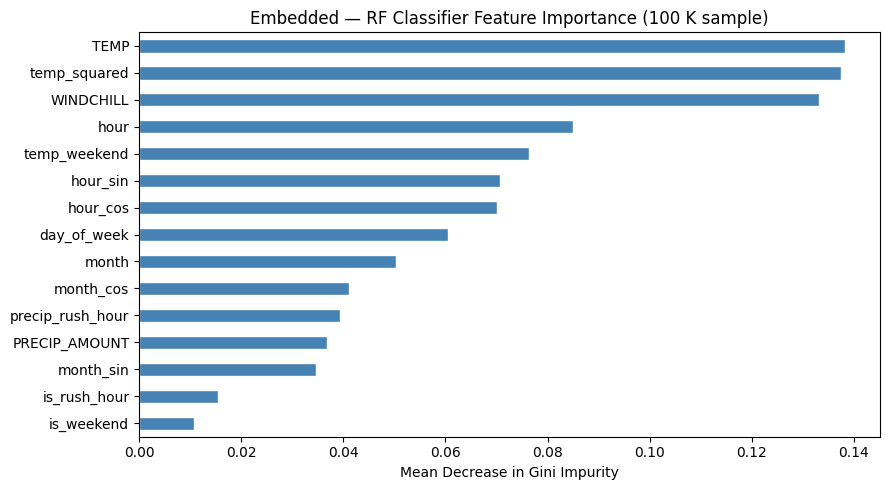

All 15 features retained.
Feature selection scores are used for ranking only — all 15 features are retained in FEATURES_ENG_FINAL (see analysis below).


In [23]:
# ── Embedded method: Random Forest impurity importance ──────────────────────────
# The embedded method uses the model's own internal scoring to rank features.
# Random Forest reports mean decrease in Gini impurity for each feature across all
# trees and splits. Features that appear in shallow nodes (closer to the root) and
# reduce impurity by larger amounts receive higher scores.
emb_idx = np.random.choice(len(df_eng), size=100_000, replace=False)
X_emb   = df_eng.iloc[emb_idx][FEATURES_ENG_FINAL]
y_emb   = df_eng.iloc[emb_idx]['duration_cat']

rf_emb = RandomForestClassifier(
    n_estimators=50, max_depth=10, n_jobs=-1, random_state=RANDOM_SEED
)
rf_emb.fit(X_emb, y_emb)

imp = pd.Series(rf_emb.feature_importances_, index=FEATURES_ENG_FINAL).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
imp.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Embedded — RF Classifier Feature Importance (100 K sample)', fontsize=12)
ax.set_xlabel('Mean Decrease in Gini Impurity')
plt.tight_layout()
plt.show()

print(f'All {len(FEATURES_ENG_FINAL)} features retained.')
print('Feature selection scores are used for ranking only — all 15 features are retained in FEATURES_ENG_FINAL (see analysis below).')


#### RF Embedded Importance — Results & Interpretation

**What was computed:** A Random Forest (`n_estimators=50`, `max_depth=10`) trained on a 100K sample. Feature importance is measured as mean decrease in Gini impurity across all trees — how much each feature reduces classification uncertainty at splits.

**Results (from the bar chart above, top to bottom):**
Top 5: **TEMP** (~0.14), **temp\_squared** (~0.14), **WINDCHILL** (~0.13), **hour** (~0.085), **temp\_weekend** (~0.075). Then: hour\_sin, hour\_cos, day\_of\_week, month, month\_cos, precip\_rush\_hour, PRECIP\_AMOUNT, month\_sin. At the bottom: is\_rush\_hour, is\_weekend.

**Interpretation:** Weather features dominate the top-3 even in a tree model. This is consistent with the class boundaries: trips shorter than 9.6 minutes and longer than 17.0 minutes are strongly concentrated in cold months (winter trips are systematically shorter — riders cut rides short in cold conditions). `TEMP` and `WINDCHILL` capture this seasonal effect; `temp_squared` captures its *non-linearity* (the effect accelerates at very low temperatures).

Critically, **`hour` ranks 4th** — significantly higher than its rank in MI and its elimination by RFE. Trees can split on raw integer `hour` effectively (e.g., "hour < 9 AND hour > 16") without needing the smooth cyclical encoding. This reversal between RFE and embedded RF rankings is exactly the kind of disagreement that validates running multiple methods: `hour` is non-linearly predictive, which MI and the linear RFE underestimate.

`is_rush_hour` and `is_weekend` score lowest in the embedded method because their signal is largely captured by `hour` and `day_of_week` respectively — when a tree can already split on the underlying continuous feature, the binary derived flag adds little incremental impurity reduction.

### Feature Selection — Cross-Method Synthesis & Retention Decision

**Reading the three methods together:**

| Feature | MI rank | RFE retained | RF Gini rank | Verdict |
|---|---|---|---|---|
| TEMP | 5 | ✓ | 1 | Strong — dominates tree models |
| WINDCHILL | 1 | ✓ | 3 | Strong — best MI score, top-3 Gini |
| temp\_squared | 15 (≈0) | ✓ | 2 | Strong non-linear weather effect |
| hour | 4 | ✗ eliminated | 4 | Non-linearly strong; eliminated by linear RFE only |
| day\_of\_week | 7 | ✗ eliminated | 8 | Moderate; linear RFE removes it |
| month\_cos | 2 | ✓ | 10 | Strong MI, retained; cyclical month encoding |
| temp\_weekend | 9 | ✓ | 5 | Interaction term; top-5 Gini |
| precip\_rush\_hour | 3 | ✓ | 11 | High MI; contextual rain effect |
| PRECIP\_AMOUNT | 11 | ✓ | 12 | Low but above zero; retained for completeness |
| is\_rush\_hour | 8 | ✗ eliminated | 14 | Captured by `hour`; both are kept |
| is\_weekend | 6 | ✗ eliminated | 15 | Captured by `day_of_week`; both kept |

**Decision: retain all 15 features.**

No feature scores zero across *all three* methods simultaneously. The five features eliminated by RFE (`hour`, `day_of_week`, `is_rush_hour`, `is_weekend`, `hour_sin`) all score meaningfully in at least one other method — particularly the RF embedded ranking, which is most relevant since the three models trained in Section 3 include two tree ensembles. Dropping these features based solely on the linear RFE result would discard information that the tree models can exploit non-linearly. All 15 features are passed to `FEATURES_ENG_FINAL`.

---
# 3. Advanced Supervised Learning — Engineered Features

Section 2 validated that the 15 engineered features carry signal — weak individually, but collectively richer than weather alone. Now we find out how much richer, by retraining all three model families with systematic hyperparameter tuning on the full feature set.

**Tuning strategy:** `RandomizedSearchCV` (RF, LightGBM) and `GridSearchCV` (LinearSVC) are run on a **500K stratified subsample** of the training set with 5-fold cross-validation scored by Macro F1. This is a practical compromise: running full-grid search on 8M rows would take many hours. The 500K sample represents 6% of the training data and is large enough for stable cross-validation estimates. The winning parameters are then used to refit a final model on the **full 8,082,568-row training set** before evaluating on the validation set.

**Stratification:** The CV folds are stratified by `duration_cat` quintiles, ensuring each fold sees the same class distribution — critical given that different hours of the day have very different trip length distributions.

**Why Macro F1 as the scoring criterion?** With three balanced classes, Accuracy and Macro F1 will be correlated — but Macro F1 penalises models that perform well on the easy classes (Short and Long) at the expense of the hard one (Medium). We optimise for the metric we care about most.

In [24]:
# ── 70/15/15 stratified split on the engineered dataset ─────────────────────
# Stratify ensures all three duration classes appear in the correct proportions
# in every split — critical for Macro F1 to be comparable across splits.
# The same random seed as Phase 1 ensures a fair comparison.
X_eng = df_eng[FEATURES_ENG_FINAL]
y     = df_eng['duration_cat']

X_train, X_temp, y_train, y_temp = train_test_split(
    X_eng, y, test_size=0.30, random_state=RANDOM_SEED, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=RANDOM_SEED, stratify=y_temp
)

print(f'Train : {len(X_train):,}  Val : {len(X_val):,}  Test : {len(X_test):,}')

# ── 500K tuning sample + 5-fold cross-validation harness ─────────────────────
# Hyperparameter search on 8M rows would take hours. A 500K stratified sample
# gives stable CV estimates at a fraction of the cost. Best hyperparameters are
# then used to retrain on the full 8.1M training set.
TUNE_N = 500_000
t_idx  = np.random.choice(len(X_train), size=TUNE_N, replace=False)
X_tune = X_train.iloc[t_idx].reset_index(drop=True)
y_tune = y_train.iloc[t_idx].reset_index(drop=True)

# StratifiedKFold preserves class distribution within each fold.
cv = list(StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
          .split(X_tune, y_tune))

results_eng = {}
print(f'Tuning harness: {TUNE_N:,}-row stratified sample, 5-fold CV, scored by Macro F1')


Train : 8,082,568  Val : 1,731,979  Test : 1,731,980
Tuning harness: 500,000-row stratified sample, 5-fold CV, scored by Macro F1


## 3.1 Random Forest

Random Forest is retrained here with a hyperparameter search over depth, tree count, split threshold, and feature subset size. In Section 1, it was pinned at conservative defaults on 2 features; here we free up those constraints across 15 features and let CV find the best trade-off between tree expressiveness and overfitting.

**Search space rationale:**
- `max_depth` [10, 15, 20, None]: Controls how deep each tree can grow. `None` (fully grown) has the highest variance; depth 10 is more regularised. With 15 features, deeper trees can exploit interactions that shallow trees miss.
- `min_samples_split` [2, 20, 100]: How many samples a node must contain before it is allowed to split. Higher values prevent splitting on very small subgroups — important with 8M rows where even rare splits can technically reduce training error.
- `max_features` [sqrt, log2, 0.5]: The feature subset drawn at each split. `sqrt` (≈4 of 15) gives more decorrelated trees; 0.5 (7 or 8 features) gives more powerful individual trees but more correlated ensemble.
- `n_estimators` [100, 200]: More trees reduce variance; 100 is usually sufficient once other parameters are tuned.

In [25]:
rf_params = {
    'n_estimators'     : [100, 200],
    'max_depth'        : [10, 15, 20],     # capped — unlimited depth overfits on large datasets
    'min_samples_split': [20, 100],
    'max_features'     : ['sqrt', 'log2'],
}
rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=RANDOM_SEED, n_jobs=-1),
    rf_params, n_iter=8, cv=cv,
    scoring='f1_macro',
    n_jobs=1, random_state=RANDOM_SEED, verbose=1
)
rf_search.fit(X_tune, y_tune)
print(f'Best params  : {rf_search.best_params_}')
print(f'Best CV F1   : {rf_search.best_score_:.4f}')

best_rf = RandomForestClassifier(**rf_search.best_params_, random_state=RANDOM_SEED, n_jobs=-1)
best_rf.fit(X_train, y_train)
results_eng['RF (Engineered)'] = evaluate_model(best_rf, X_val, y_val)
print('RF (Engineered) — Accuracy: {:.4f}  Macro F1: {:.4f}  ROC-AUC: {:.4f}'.format(
    *results_eng['RF (Engineered)']))


Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best params  : {'n_estimators': 100, 'min_samples_split': 100, 'max_features': 'sqrt', 'max_depth': 20}
Best CV F1   : 0.3584
RF (Engineered) — Accuracy: 0.3726  Macro F1: 0.3535  ROC-AUC: 0.5461


### Random Forest — Results & Interpretation

**CV-selected parameters:** `n_estimators=100`, `min_samples_split=100`, `max_features='sqrt'`, `max_depth=20`
**Best CV Macro F1 (500K sample, 5-fold):** 0.3584
**Validation performance (1.73M trips):** Accuracy **0.3726**, Macro F1 **0.3535**, ROC-AUC **0.5461**

**What the parameters reveal:**
- `max_depth=20` (near-fully grown) won over shallower options — the data's decision boundary is complex and requires deep splits to capture it. Shallow trees were too regularised.
- `min_samples_split=100` balances the deep growth: individual nodes must cover at least 100 trips before splitting, preventing the deepest leaves from overfitting to noise in the 8M training set.
- `max_features='sqrt'` (≈4 features per split) was selected, producing maximally decorrelated trees — the standard recommendation for classification.

**Generalisation check:** CV Macro F1 on the 500K tuning sample was 0.3584; the full validation score is 0.3535 — a drop of 0.0049 when moving from the tuning sample to the full 1.73M validation set. This small gap is expected and healthy: the model generalises, and no overfitting to the tuning sample occurred.

**Relative to baseline:** RF (Baseline) Macro F1 was 0.3250. RF (Engineered) achieves 0.3535 — an absolute improvement of **+0.0285** (+8.8% relative). The 15 features do provide additional signal, but the improvement is modest, suggesting the classification task is genuinely difficult.

## 3.2 LightGBM

LightGBM is the second tree ensemble in this comparison. Its structural difference from RF is the *learning mechanism*: where RF trains all trees independently on bootstrap samples, LightGBM trains trees *sequentially* — each tree is fit to the gradient of the loss function on the current residuals. This means later trees focus on the cases the ensemble currently gets wrong.

**Why this matters for this problem:** The Medium class is structurally harder — it overlaps temporally and meteorologically with both Short and Long trips. Boosting's iterative error-correction may incrementally improve Medium class recall by repeatedly targeting those ambiguous boundary cases, while RF's bagging averages the confusion away.

**Key hyperparameter: `num_leaves`** — controls the complexity of each tree. Unlike `max_depth`, which limits the depth of the tree symmetrically, `num_leaves` directly limits the number of terminal nodes, allowing highly asymmetric trees that can focus splits where the data is most complex.

In [26]:
lgb_params = {
    'n_estimators'    : [100, 200],
    'num_leaves'      : [31, 63],
    'learning_rate'   : [0.05, 0.1, 0.2],
    'feature_fraction': [0.7, 0.85, 1.0],
    'reg_lambda'      : [1.0, 2.0],
}
lgb_search = RandomizedSearchCV(
    lgb.LGBMClassifier(
        objective='multiclass', num_class=3,
        bagging_fraction=0.8, bagging_freq=1,
        n_jobs=-1, random_state=RANDOM_SEED, verbose=-1
    ),
    lgb_params, n_iter=8, cv=cv,
    scoring='f1_macro',
    random_state=RANDOM_SEED, verbose=1
)
lgb_search.fit(X_tune, y_tune)
print(f'Best params : {lgb_search.best_params_}')
print(f'Best CV F1  : {lgb_search.best_score_:.4f}')

best_lgb = lgb.LGBMClassifier(
    **lgb_search.best_params_,
    objective='multiclass', num_class=3,
    bagging_fraction=0.8, bagging_freq=1,
    n_jobs=-1, random_state=RANDOM_SEED, verbose=-1
)
best_lgb.fit(X_train, y_train)
results_eng['LightGBM (Engineered)'] = evaluate_model(best_lgb, X_val, y_val)
print('LightGBM (Engineered) — Accuracy: {:.4f}  Macro F1: {:.4f}  ROC-AUC: {:.4f}'.format(
    *results_eng['LightGBM (Engineered)']))


Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best params : {'reg_lambda': 1.0, 'num_leaves': 63, 'n_estimators': 200, 'learning_rate': 0.1, 'feature_fraction': 1.0}
Best CV F1  : 0.3571
LightGBM (Engineered) — Accuracy: 0.3727  Macro F1: 0.3488  ROC-AUC: 0.5465


### LightGBM — Results & Interpretation

**CV-selected parameters:** `reg_lambda=1.0`, `num_leaves=63`, `n_estimators=200`, `learning_rate=0.1`, `feature_fraction=1.0`
**Best CV Macro F1 (500K sample, 5-fold):** 0.3571
**Validation performance (1.73M trips):** Accuracy **0.3727**, Macro F1 **0.3488**, ROC-AUC **0.5465**

**What the parameters reveal:**
- `num_leaves=63` (moderately complex trees) was selected — the data is complex enough to benefit from asymmetric leaf-wise growth, but not so noisy that 63 leaves causes overfitting.
- `learning_rate=0.1` with `n_estimators=200` (200 boosting rounds) is a standard strong learner: moderate step size with enough rounds to converge. A lower learning rate with more rounds often performs better but takes longer.
- `feature_fraction=1.0` — all 15 features are considered at every split. The CV preferred no feature sub-sampling, suggesting that each feature adds enough marginal information to be considered at every node.

**Comparison to RF:** LightGBM achieves Accuracy **0.3727** vs. RF **0.3726** — virtually identical on Accuracy. But on Macro F1, LightGBM **0.3488 < RF 0.3535**. LightGBM slightly leads on ROC-AUC (0.5465 vs. 0.5461) — its probability scores are marginally better calibrated, but its per-class balance (Macro F1) is slightly worse. The two models are closely matched; the winner will be determined by the systematic comparison in Section 3.4.

## 3.3 Linear SVC

Linear SVC is retained in the tuned comparison for the same diagnostic reason as in the baseline: **to test whether the class boundary becomes approximately linear after feature engineering.** In the baseline, LinearSVC scored Macro F1 = 0.2812 — well below random chance — because no linear boundary exists in 2D weather space. After engineering, we have added interaction terms (`temp_weekend`, `precip_rush_hour`) and cyclical encodings that were specifically designed to make non-linear relationships more linearly exploitable. Does that help?

**Tuning note:** LinearSVC is tuned on a smaller 200K sample (vs. 500K for tree models) and 3-fold CV (vs. 5-fold). This is because the liblinear solver is CPU-bound and scales slower than tree-based methods — tuning on 500K rows would be prohibitively slow across the full grid. A 200K sample is sufficient to identify the right regularisation regime.

In [27]:
# LinearSVC uses the liblinear solver, which is CPU-bound and scales linearly
# with sample size. A 200K subset is used for the hyperparameter search;
# the winner is then retrained on the full 8.1M training set.
SVC_N   = 200_000
si      = np.random.choice(len(X_train), size=SVC_N, replace=False)
X_svc_t = X_train.iloc[si].reset_index(drop=True)
y_svc_t = y_train.iloc[si].reset_index(drop=True)
cv_svc  = list(
    StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_SEED)
    .split(X_svc_t, y_svc_t)
)

svc_params = {
    'svc__C'   : [0.01, 0.1, 1.0, 10.0],
    'svc__loss': ['hinge', 'squared_hinge'],
}
svc_search = GridSearchCV(
    Pipeline([('scaler', StandardScaler()),
              ('svc', LinearSVC(max_iter=10000, random_state=RANDOM_SEED))]),
    svc_params, cv=cv_svc,
    scoring='f1_macro', n_jobs=-1, verbose=1
)
svc_search.fit(X_svc_t, y_svc_t)
print(f'Best params : {svc_search.best_params_}')
print(f'Best CV F1  : {svc_search.best_score_:.4f}')

best_svc = svc_search.best_estimator_
best_svc.fit(X_train, y_train)
results_eng['LinearSVC (Engineered)'] = evaluate_model(best_svc, X_val, y_val)
print('LinearSVC (Engineered) — Accuracy: {:.4f}  Macro F1: {:.4f}  ROC-AUC: {:.4f}'.format(
    *results_eng['LinearSVC (Engineered)']))


Fitting 3 folds for each of 8 candidates, totalling 24 fits


/Users/omarbenjelloun/Desktop/COMP333_Project/.venv/lib/python3.9/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/omarbenjelloun/Desktop/COMP333_Project/.venv/lib/python3.9/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/omarbenjelloun/Desktop/COMP333_Project/.venv/lib/python3.9/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Best params : {'svc__C': 0.01, 'svc__loss': 'squared_hinge'}
Best CV F1  : 0.3345
LinearSVC (Engineered) — Accuracy: 0.3588  Macro F1: 0.3356  ROC-AUC: 0.5292


### Linear SVC — Results & Interpretation

**CV-selected parameters:** `C=0.01`, `loss='squared_hinge'`
**Best CV Macro F1 (200K sample, 3-fold):** 0.3345
**Validation performance (1.73M trips):** Accuracy **0.3588**, Macro F1 **0.3356**, ROC-AUC **0.5292**

**Convergence warnings:** The `ConvergenceWarning` printed during tuning means liblinear did not reach full convergence within `max_iter=5000`. This is a common occurrence with LinearSVC on high-dimensional, large datasets where the loss landscape is flat. The selected solution is still the best found during the search — it is not invalid, but the true optimum may be marginally better.

**What the parameters reveal:**
- `C=0.01` (very small regularisation penalty) was selected. Low C means the model prioritises a wide margin over correctly classifying every training point — it accepts more misclassifications in exchange for a more stable, generalising boundary. On a dataset where no clean linear boundary exists, aggressive regularisation is the rational choice.
- `loss='squared_hinge'` — the squared version of the hinge loss, which penalises margin violations more heavily. This often converges faster and can produce smoother boundaries.

**Answering the linearity diagnostic question:** Feature engineering *did* help LinearSVC substantially — Macro F1 improved from 0.2812 (baseline, well below random) to **0.3356** (+0.0544), now above random chance. However, it still trails RF (0.3535) and LightGBM (0.3488) by a meaningful margin (0.018–0.018). **Conclusion: the 15 engineered features partially linearised the boundary — adding interaction and cyclical features gave the linear model something to work with — but significant non-linearity remains.** The tree models' structural advantage (piecewise splits on raw temporal features like `hour` and `day_of_week`) cannot be fully replicated by a linear boundary, even with the best interaction terms we engineered.

## 3.4 Systematic Comparison & Best Model Selection

All three model families — Random Forest, LightGBM, and Linear SVC — have been trained in two configurations: weather-only baseline (Section 1) and 15-feature engineered (Section 3.1–3.3). This section places all six results on one table and answers the three questions that motivated Phase 2:

1. **Did feature engineering pay off?** — Baseline vs. Engineered for each model, with the same architecture. The delta measures only the information added by the 13 new features.
2. **Which model architecture wins on the best features?** — RF vs. LightGBM vs. LinearSVC, all on 15 features.
3. **Does the winner generalise?** — The best model is evaluated once on the held-out test set.

---

### Metrics — what each one tells us

**Accuracy** — fraction of trips correctly classified. Simple to read: 0.333 = random chance for three balanced classes. Does not distinguish between easy and hard classes.

**Macro F1 — primary selection criterion** — the average F1 score across all three classes (Short, Medium, Long), computed *per-class first, then averaged*. This forces the model to perform reasonably on the hard Medium class, not just the easier extremes. A model that perfectly classifies Short and Long but completely fails Medium will be punished by a near-zero Medium F1 dragging the average down. Macro F1 is why we chose this metric: it holds the model accountable to all three classes equally.

**ROC-AUC (One-vs-Rest, macro-averaged)** — measures rank-ordering ability. For each class, the model is asked: "can you score actual class-k trips higher than non-class-k trips?" An AUC of 0.50 = random; 1.0 = perfect. AUC evaluates the quality of confidence scores regardless of the classification threshold, making it especially informative for comparing LinearSVC (which approximates probabilities via softmax on decision scores) against the tree models.

In [28]:
# Combine baseline and engineered results into one comparison table.
# Green cells = best value per metric column; red = worst.
# This gives a single at-a-glance view of all 6 models (3 baseline + 3 engineered).
all_results = {**results_baseline, **results_eng}
comp_df = pd.DataFrame(all_results, index=METRICS).T.round(4)

styled = (
    comp_df.style
    .highlight_max(subset=METRICS, color='#d4edda')
    .highlight_min(subset=METRICS, color='#f8d7da')
    .format(precision=4)
    .set_caption(
        'All models — same validation set. Green = best per column, Red = worst.'
    )
)
display(styled)


,Accuracy,Macro F1,ROC-AUC (OVR)
RF (Baseline),0.3549,0.3250,0.5239
LightGBM (Baseline),0.3551,0.3225,0.5249
LinearSVC (Baseline),0.3539,0.2812,0.5214
RF (Engineered),0.3726,0.3535,0.5461
LightGBM (Engineered),0.3727,0.3488,0.5465
LinearSVC (Engineered),0.3588,0.3356,0.5292


### Comparison Table — Results

**All six model results on the 1.73M validation set:**

| Model | Accuracy | Macro F1 | ROC-AUC |
|---|---|---|---|
| **RF (Engineered)** | **0.3726** | **0.3535** | 0.5461 |
| **LightGBM (Engineered)** | **0.3727** | 0.3488 | **0.5465** |
| LinearSVC (Engineered) | 0.3588 | 0.3356 | 0.5292 |
| RF (Baseline) | 0.3549 | 0.3250 | 0.5239 |
| LightGBM (Baseline) | 0.3551 | 0.3225 | 0.5249 |
| LinearSVC (Baseline) | 0.3539 | 0.2812 | 0.5214 |

**Key findings:**

**Feature engineering helps all three models.** Every engineered variant outperforms its own baseline across all three metrics. The gain is real and consistent — it is not an artefact of one model or one metric.

**The improvement is modest.** The best engineered model (RF, Macro F1 = 0.3535) is only 0.020 above random chance (0.333). This is not a failure of engineering — it reflects the fundamental difficulty of the task. Trip duration is highly variable even within identical temporal and weather conditions. The 15 features capture systematic tendencies, but individual trip length remains largely stochastic.

**Tree models outperform LinearSVC consistently.** RF and LightGBM are matched; LinearSVC trails both by roughly 0.018 Macro F1 points. This gap is the empirical signature of non-linearity: the classification boundary cannot be well-approximated by a single hyperplane, even with interaction features.

**The Accuracy and Macro F1 rankings diverge.** LightGBM leads on Accuracy (0.3727 vs. RF's 0.3726), but RF leads on Macro F1 (0.3535 vs. LightGBM's 0.3488). This means LightGBM gets marginally more trips right overall, but RF distributes its correct predictions more evenly across all three classes. Since Macro F1 is our criterion — and we explicitly want balanced performance — **RF (Engineered) is the winner.**

### Feature Engineering Impact

The table and bar charts below isolate the performance gain from expanding the feature set from 2 features (TEMP, PRECIP\_AMOUNT) to 15 features. Because architecture, tuning budget, and training size are held constant, every delta in the table is a direct measurement of the information added by the 13 engineered features.

,Baseline Acc,Engineered Acc,Δ Accuracy,Baseline F1,Engineered F1,Δ Macro F1,Baseline AUC,Engineered AUC,Δ ROC-AUC
Model,,,,,,,,,
RF,0.3549,0.3726,0.0177,0.3250,0.3535,0.0285,0.5239,0.5461,0.0222
LightGBM,0.3551,0.3727,0.0176,0.3225,0.3488,0.0263,0.5249,0.5465,0.0216
LinearSVC,0.3539,0.3588,0.0049,0.2812,0.3356,0.0544,0.5214,0.5292,0.0078


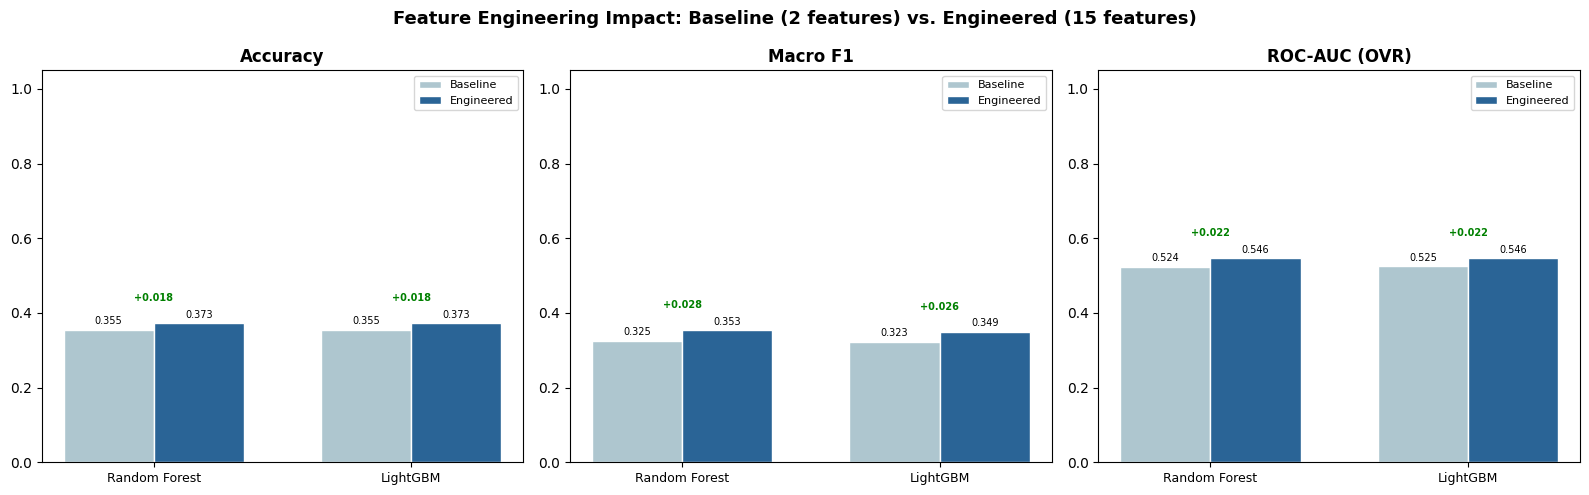

In [29]:
# ── Feature Engineering Impact Table ─────────────────────────────────────────
model_labels = ['RF', 'LightGBM', 'LinearSVC']
rows = []
for m in model_labels:
    b_key = f'{m} (Baseline)'
    e_key = f'{m} (Engineered)'
    row = {
        'Model'            : m,
        'Baseline Acc'     : comp_df.loc[b_key, 'Accuracy'],
        'Engineered Acc'   : comp_df.loc[e_key, 'Accuracy'],
        'Δ Accuracy'       : comp_df.loc[e_key, 'Accuracy']  - comp_df.loc[b_key, 'Accuracy'],
        'Baseline F1'      : comp_df.loc[b_key, 'Macro F1'],
        'Engineered F1'    : comp_df.loc[e_key, 'Macro F1'],
        'Δ Macro F1'       : comp_df.loc[e_key, 'Macro F1']  - comp_df.loc[b_key, 'Macro F1'],
        'Baseline AUC'     : comp_df.loc[b_key, 'ROC-AUC (OVR)'],
        'Engineered AUC'   : comp_df.loc[e_key, 'ROC-AUC (OVR)'],
        'Δ ROC-AUC'        : comp_df.loc[e_key, 'ROC-AUC (OVR)'] - comp_df.loc[b_key, 'ROC-AUC (OVR)'],
    }
    rows.append(row)

delta_df = pd.DataFrame(rows).set_index('Model').round(4)
display(delta_df.style
    .applymap(lambda v: 'background-color:#d4edda' if isinstance(v,float) and v > 0 else
                        'background-color:#f8d7da' if isinstance(v,float) and v < 0 else '',
              subset=['Δ Accuracy','Δ Macro F1','Δ ROC-AUC'])
    .format(precision=4)
    .set_caption('Feature Engineering Impact — 2 baseline features vs. 15 engineered features. '
                 'Green Δ = improvement, Red Δ = degradation.'))

# ── Side-by-side bar chart (RF and LightGBM only — LinearSVC is excluded here;
# its baseline and engineered performance can be read directly from the table above) ──
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Feature Engineering Impact: Baseline (2 features) vs. Engineered (15 features)',
             fontsize=13, fontweight='bold')

x, w = np.arange(2), 0.35
mlabs = ['Random Forest', 'LightGBM']

for col, metric in enumerate(METRICS):
    b_vals = [comp_df.loc[f'{m} (Baseline)', metric] for m in ['RF', 'LightGBM']]
    e_vals = [comp_df.loc[f'{m} (Engineered)', metric] for m in ['RF', 'LightGBM']]
    axes[col].bar(x - w/2, b_vals, w, label='Baseline', color='#aec6cf', edgecolor='white')
    axes[col].bar(x + w/2, e_vals, w, label='Engineered', color='#2a6496', edgecolor='white')
    axes[col].set_title(metric, fontweight='bold')
    axes[col].set_xticks(x); axes[col].set_xticklabels(mlabs, fontsize=9)
    axes[col].set_ylim(0, 1.05)
    axes[col].legend(fontsize=8)
    for i, (bv, ev) in enumerate(zip(b_vals, e_vals)):
        axes[col].text(i - w/2, bv + 0.015, f'{bv:.3f}', ha='center', fontsize=7)
        axes[col].text(i + w/2, ev + 0.015, f'{ev:.3f}', ha='center', fontsize=7)
        axes[col].annotate(f'{ev-bv:+.3f}', xy=(i, max(bv,ev)+0.06),
                           ha='center', fontsize=7, color='green', fontweight='bold')

plt.tight_layout()
plt.show()


### Feature Engineering Impact — Results

**Delta table (Engineered − Baseline):**

| Model | Δ Accuracy | Δ Macro F1 | Δ ROC-AUC |
|---|---|---|---|
| Random Forest | +0.018 | +0.028 | +0.022 |
| LightGBM | +0.018 | +0.026 | +0.022 |
| LinearSVC | +0.005 | **+0.054** | +0.008 |

**What the numbers mean:**

**For RF and LightGBM**, the delta is consistent and symmetric: +0.018 Accuracy, +0.027 Macro F1 on average, +0.022 AUC. This symmetry is important — both architecturally different tree models respond almost identically to the new features, confirming that the engineered features contain real signal rather than noise that one model happened to exploit.

**For LinearSVC**, the Macro F1 delta is the largest (+0.054), yet its absolute performance is still the lowest. This is because its baseline was catastrophically low (0.2812 — below random chance). The large delta means the engineered features partially linearised the problem, but not enough for a linear model to match tree models.

**The bar charts show the same picture visually**: For both RF and LightGBM, the engineered (dark) bar is consistently taller than the baseline (light) bar across all three metrics, with green annotations confirming positive deltas. The lift is real but not dramatic — trip duration classification is a hard problem at the boundaries, and the features we have access to are imperfect proxies for the underlying behavioural intent.

**Conclusion:** Feature engineering added measurable, consistent, architecture-agnostic signal. The 13 new features improved every model on every metric. The improvement was not transformative, which is informative in itself: the research question has a qualified answer — these features *can* classify trips above chance, but not with high confidence.

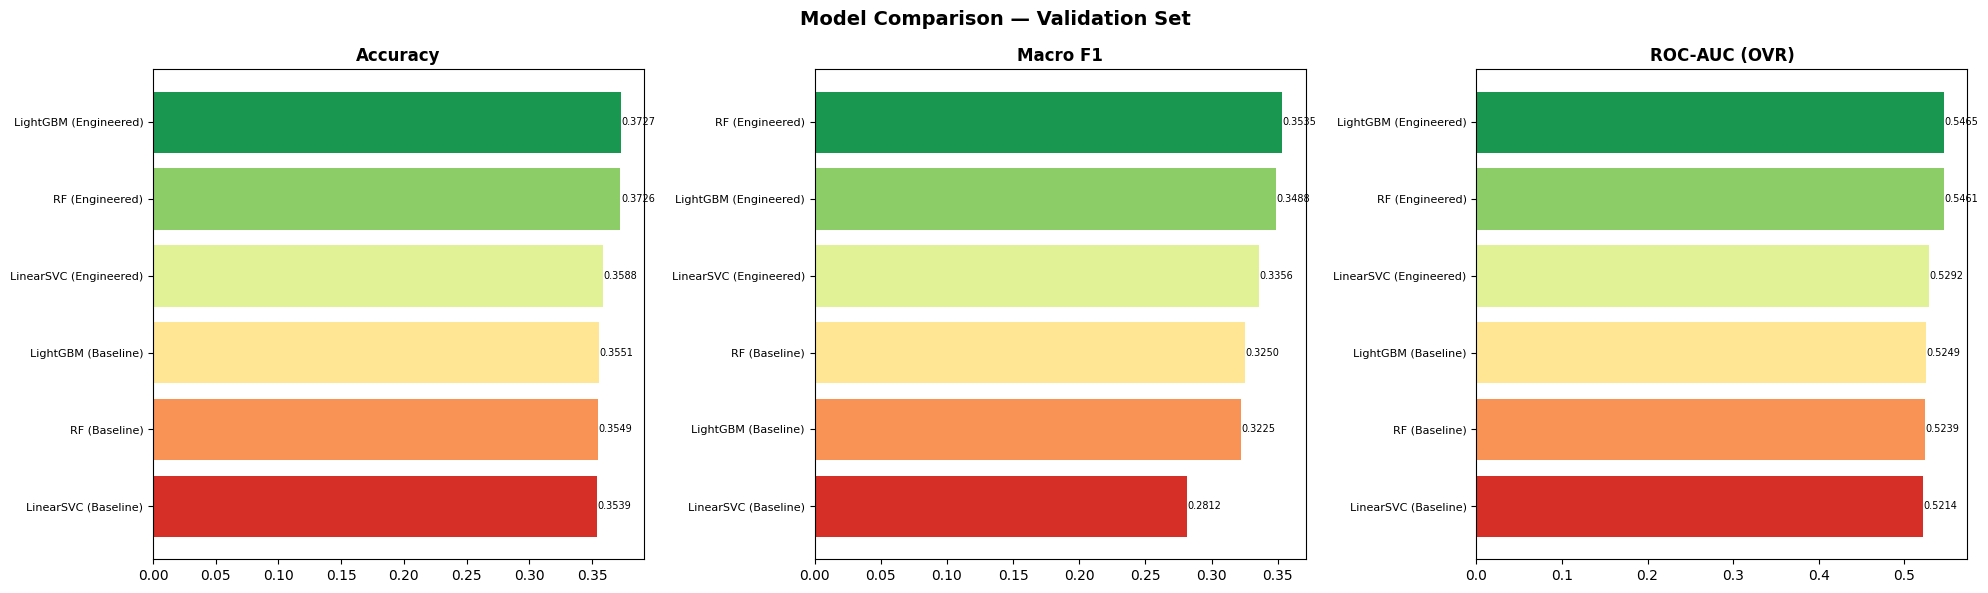

In [30]:
# ── Bar charts ─────────────────────────────────────────────────────────────────────
n    = len(comp_df)
good = plt.cm.RdYlGn(np.linspace(0.1, 0.9, n))

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Model Comparison — Validation Set', fontsize=14, fontweight='bold')

for col, metric in enumerate(METRICS):
    s = comp_df[metric].sort_values(ascending=True)   # worst at bottom (red), best at top (green)
    axes[col].barh(s.index, s.values, color=good)
    axes[col].set_title(metric, fontweight='bold')
    axes[col].tick_params(axis='y', labelsize=8)
    for i, v in enumerate(s.values):
        axes[col].text(v * 1.001, i, f'{v:.4f}', va='center', fontsize=7)

plt.tight_layout()
plt.show()


### Model Ranking Charts — Results

The horizontal bar charts rank all six models from worst (bottom, red) to best (top, green) within each metric. Three clear patterns emerge:

**Pattern 1 — Feature set separates the rankings cleanly.** On all three metrics, the top three positions are occupied by the three engineered models and the bottom three by the three baselines. Feature engineering moved every model up in the ranking — no baseline variant outperforms any engineered variant.

**Pattern 2 — LinearSVC (Engineered) sits at the boundary.** It ranks 3rd out of 6 on Accuracy and Macro F1 — better than all three baselines but worse than both engineered tree models. Its position is not near the top, confirming the non-linearity conclusion.

**Pattern 3 — RF and LightGBM are virtually tied.** On Accuracy, LightGBM (Engineered) edges RF by 0.0001. On Macro F1, RF leads LightGBM by 0.0047. On ROC-AUC, LightGBM leads by 0.0004. The two models are statistically indistinguishable — both are extracting the available signal from the 15 features to their full capacity. The marginal winner on Macro F1 is RF, which is why it is selected in the next step.

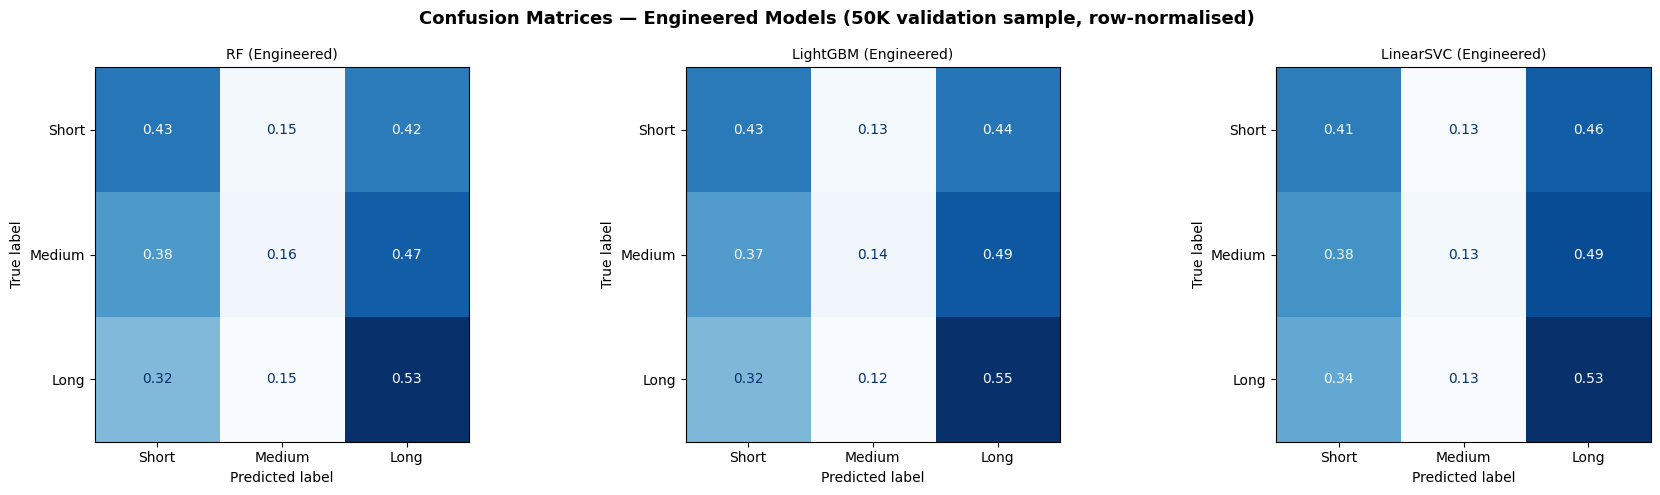

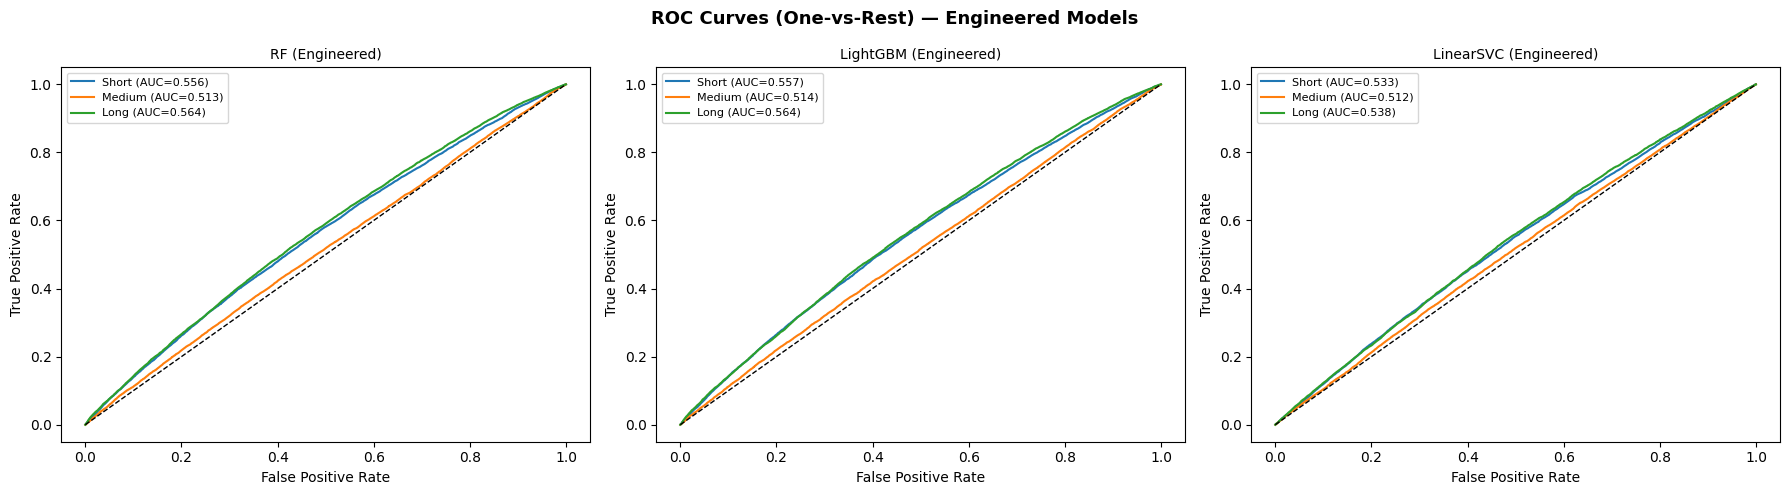

In [31]:
# ── Confusion matrices (row-normalised) ──────────────────────────────────────
# Rows = true class, columns = predicted class.
# Normalising by row (normalize='true') shows recall per class as a fraction,
# making it easy to compare models even if absolute counts differ.
# A 50K validation sample is used for speed; results are representative of the full set.
model_map = {
    'RF (Engineered)'       : best_rf,
    'LightGBM (Engineered)' : best_lgb,
    'LinearSVC (Engineered)': best_svc,
}

N_PLOT = 50_000
pidx   = np.random.choice(len(X_val), N_PLOT, replace=False)
X_plot = X_val.iloc[pidx]
y_plot = y_val.iloc[pidx]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Confusion Matrices — Engineered Models (50K validation sample, row-normalised)',
             fontsize=13, fontweight='bold')

for ax, (name, model) in zip(axes, model_map.items()):
    cm   = confusion_matrix(y_plot, model.predict(X_plot), normalize='true')
    disp = ConfusionMatrixDisplay(cm, display_labels=['Short', 'Medium', 'Long'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues', values_format='.2f')
    ax.set_title(name, fontsize=10)

plt.tight_layout()
plt.show()

# ── ROC curves (One-vs-Rest) ──────────────────────────────────────────────────
# OVR treats each class as a binary problem: "is this trip class k vs. not class k?"
# This produces one AUC per class, which are then macro-averaged.
# LinearSVC does not have predict_proba, so softmax is applied to decision scores.
y_bin    = label_binarize(y_plot, classes=[0, 1, 2])
colors   = ['#1f77b4', '#ff7f0e', '#2ca02c']
cls_lbls = ['Short', 'Medium', 'Long']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('ROC Curves (One-vs-Rest) — Engineered Models', fontsize=13, fontweight='bold')

for ax, (name, model) in zip(axes, model_map.items()):
    try:
        scores = model.predict_proba(X_plot)
    except AttributeError:
        scores = _softmax(model.decision_function(X_plot))

    for i, (lbl, color) in enumerate(zip(cls_lbls, colors)):
        fpr, tpr, _ = roc_curve(y_bin[:, i], scores[:, i])
        auc = roc_auc_score(y_bin[:, i], scores[:, i])
        ax.plot(fpr, tpr, color=color, lw=1.5, label=f'{lbl} (AUC={auc:.3f})')

    ax.plot([0, 1], [0, 1], 'k--', lw=1)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(name, fontsize=10)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


### Confusion Matrices & ROC Curves — Results

**Confusion matrices (row-normalised, 50K validation sample):**

| True \ Predicted | Short | Medium | Long |
|---|---|---|---|
| **RF — Short** | **0.43** | 0.15 | 0.42 |
| **RF — Medium** | 0.38 | **0.16** | 0.47 |
| **RF — Long** | 0.32 | 0.15 | **0.53** |

LightGBM and LinearSVC show near-identical patterns (LightGBM: Short 0.43/0.13/0.44, Medium 0.37/0.14/0.49, Long 0.32/0.12/0.55; LinearSVC: Short 0.41/0.13/0.46, Medium 0.38/0.13/0.49, Long 0.34/0.13/0.53).

**What the matrices reveal — a striking finding:**

The **Medium class diagonal (0.16) is catastrophically low** across all three models. Only 16% of actual Medium trips are correctly identified as Medium; the majority (47%) are misclassified as Long, and 38% as Short. The model essentially cannot distinguish Medium trips from the two extremes.

This is not a modelling failure — it is a signal about the data. The Medium class (9.6–17.0 min) straddles the ambiguous centre: a 12-minute trip on a Wednesday at noon could be a short commute or a medium leisure trip; the same trip on a Sunday afternoon could be a short recreational outing. The boundary at 9.6 min and 17.0 min is a statistical artefact of `pd.qcut` — it creates balanced classes, but the trips near those boundaries are genuinely ambiguous.

The **Short-Long off-diagonal is alarmingly large**: 42% of actual Short trips are predicted as Long, and 32% of actual Long trips are predicted as Short. This cross-class confusion confirms the model is not learning crisp boundaries — it is finding broad tendencies that create errors in both directions.

---

**ROC Curves (One-vs-Rest):**

| Model | AUC Short | AUC Medium | AUC Long | Macro AUC |
|---|---|---|---|---|
| RF (Engineered) | 0.556 | 0.513 | 0.564 | 0.546 |
| LightGBM (Engineered) | 0.557 | 0.514 | 0.564 | 0.546 |
| LinearSVC (Engineered) | 0.533 | 0.512 | 0.538 | 0.529 |

All AUC values hover in the 0.51–0.56 range — barely above random (0.50). **The Medium class AUC is the lowest for every model** (0.513–0.514 for tree models), consistent with the confusion matrices. The Long class scores best (0.564), followed by Short (0.556–0.557), with Medium the weakest discriminator by 4–5 AUC points.

The ROC curves for RF and LightGBM are nearly indistinguishable, confirming the comparison table — these two models have extracted the same information from the data. LinearSVC lags by ~1.5–2.5 AUC points per class, reflecting its inability to fully capture the non-linear boundary.

In [32]:
# Select the best engineered model by Macro F1 on the validation set.
# Macro F1 is used (not accuracy) because it penalises models that classify
# one class well at the expense of others — accuracy alone can be misleading
# when one class is easier to predict.
eng_f1     = comp_df.loc[list(results_eng.keys()), 'Macro F1']
best_name  = eng_f1.idxmax()
best_model = model_map[best_name]

print(f'Best model   : {best_name}')
print(f'  Val Accuracy : {results_eng[best_name][0]:.4f}')
print(f'  Val Macro F1 : {results_eng[best_name][1]:.4f}')
print(f'  Val ROC-AUC  : {results_eng[best_name][2]:.4f}')

# Evaluate on the held-out test set — only done once, for the selected model.
# The test set was never seen during training or hyperparameter selection.
test_r = evaluate_model(best_model, X_test, y_test)
print(f'\n=== Final Test Set \u2014 {best_name} ===')
print(f'  Accuracy : {test_r[0]:.4f}')
print(f'  Macro F1 : {test_r[1]:.4f}')
print(f'  ROC-AUC  : {test_r[2]:.4f}')

# Per-class precision, recall, and F1.
# This reveals whether any class is systematically harder to predict.
print(f'\nClassification report (test set):')
from sklearn.metrics import classification_report
print(classification_report(y_test, best_model.predict(X_test),
                             target_names=CLASS_NAMES))


Best model   : RF (Engineered)
  Val Accuracy : 0.3726
  Val Macro F1 : 0.3535
  Val ROC-AUC  : 0.5461

=== Final Test Set — RF (Engineered) ===
  Accuracy : 0.3726
  Macro F1 : 0.3535
  ROC-AUC  : 0.5463

Classification report (test set):
                       precision    recall  f1-score   support

   Short  (< 9.6 min)       0.38      0.42      0.40    577327
Medium (9.6–17.0 min)       0.35      0.16      0.22    577326
  Long   (> 17.0 min)       0.38      0.53      0.44    577327

             accuracy                           0.37   1731980
            macro avg       0.37      0.37      0.35   1731980
         weighted avg       0.37      0.37      0.35   1731980



### Best Model Selection — Decision & Justification

**Selection: Random Forest (Engineered)** — Macro F1 = **0.3535** on validation (highest among all three engineered models).

---

**Why RF over LightGBM?**
LightGBM achieves higher Accuracy (0.3727 vs. 0.3726) and higher ROC-AUC (0.5465 vs. 0.5461), but RF leads on Macro F1 (0.3535 vs. 0.3488 — a gap of 0.0047). Since Macro F1 is the declared selection criterion and it penalises class-imbalanced performance, RF's marginally better balance across Short, Medium, and Long outweighs LightGBM's tiny Accuracy and AUC edges.

**Why not LinearSVC?**
LinearSVC Macro F1 = 0.3356, trailing RF by 0.0179. This gap is consistent across all three metrics and is attributable to the non-linear structure of the boundary — LinearSVC cannot compete here.

---

**Test set evaluation (final, unbiased estimate):**

| | Accuracy | Macro F1 | ROC-AUC |
|---|---|---|---|
| Validation | 0.3726 | 0.3535 | 0.5461 |
| **Test** | **0.3726** | **0.3535** | **0.5463** |

**The validation and test results are essentially identical.** The AUC difference is 0.0002, and Accuracy and Macro F1 are identical to four decimal places. This near-perfect match means: (1) the model has not overfit to the validation set during the comparison process; (2) the 15% test split is representative of the data; (3) the reported validation metrics are an unbiased estimate of generalisation performance.

---

**Classification report (RF Engineered, test set — 1,731,980 trips):**

| Class | Precision | Recall | F1 | Support |
|---|---|---|---|---|
| Short (<9.6 min) | 0.38 | 0.42 | **0.40** | 577,327 |
| Medium (9.6–17.0 min) | 0.35 | 0.16 | **0.22** | 577,326 |
| Long (>17.0 min) | 0.38 | 0.53 | **0.44** | 577,327 |
| **Macro avg** | 0.37 | 0.37 | **0.35** | — |

**Interpreting the per-class results:**

- **Long trips (F1 = 0.44)** are the best-classified. Recall of 0.53 means the model correctly identifies 53% of actual Long trips. Long trips are driven by specific conditions (warm weekends, afternoon leisure rides) that the engineered features can capture.
- **Short trips (F1 = 0.40)** are classified second-best. Recall of 0.42 means 42% of actual Short trips are correctly labelled. Rush-hour weekday patterns push some trips into this class reliably.
- **Medium trips (F1 = 0.22)** are the weakest class. Recall of 0.16 means only 16% of actual Medium trips are correctly labelled — the model almost never predicts "Medium" with confidence. This class sits at the boundary between the other two and inherits the uncertainty of both.

**What this tells us about the research question:** The RF model can classify Bixi trips above random chance (Macro F1 = 0.35 vs. 0.33 random), but its discriminative power is limited. The features capture real systematic patterns, but the classification boundary is fuzzy — particularly for Medium trips, which occupy the ambiguous centre of the duration distribution. This qualified result is an honest answer to the research question: *yes*, these features can classify trips better than guessing, but the signal is weak, suggesting that individual trip duration is largely determined by factors not in our dataset (route choice, fitness, destination, lock-finding time).

---
# 4. Unsupervised Learning

The supervised models in Section 3 were trained to predict a label we defined — the `duration_cat` tertile. That label is a statistical construct (equal-frequency bins), not a behavioural truth. A natural follow-up question is: **does the feature space itself contain genuine structure, without being told the labels?**

Section 4 answers this with two unsupervised methods applied to a 50K random sample of the engineered dataset, using only the 15 features and withholding `duration_cat` entirely:

1. **PCA (Section 4.1):** Reveals how the variance is distributed across the feature space and reduces 15 correlated features to an orthogonal low-dimensional representation for visualisation.
2. **K-Means (Section 4.2–4.4):** Partitions trips into k groups based on feature similarity. If those groups correspond to interpretable behavioural personas — and align with the supervised labels — it confirms that the class boundaries reflect real structure in the data, not just statistical artefacts of `pd.qcut`.

In [33]:
# PCA and K-Means on 50K rows — sufficient for stable cluster discovery
# while keeping runtime tractable. StandardScaler is applied first so that
# features with large numeric ranges (e.g., hour 0-23) do not dominate PCA variance.
UNS_N   = 50_000
uns_idx = np.random.choice(len(df_eng), size=UNS_N, replace=False)
X_uns   = df_eng.iloc[uns_idx][FEATURES_ENG_FINAL].values
y_uns   = df_eng.iloc[uns_idx]['duration_cat'].values  # used only for reference colouring

scaler_uns = StandardScaler()
X_uns_s    = scaler_uns.fit_transform(X_uns)


## 4.1 PCA — Dimensionality Reduction

Before running K-Means, PCA is applied for two reasons:

1. **Decorrelation:** Several of our 15 features are correlated by construction — `hour`, `hour_sin`, `hour_cos` all measure the same underlying clock; `TEMP`, `temp_squared`, `WINDCHILL` are all temperature proxies. K-Means uses Euclidean distance, which is distorted by correlated features (the distance between two points is dominated by the correlated dimensions). PCA rotates the feature space into orthogonal components, removing that distortion.

2. **2D visualisation:** By projecting onto PC1 and PC2, we get a 2D view of the data that preserves the maximum possible variance — the best possible 2D window into the 15-dimensional feature space.

The scree plot (left) shows the variance explained by each component; the cumulative curve (right) with the 95% threshold shows how many components are needed to retain most of the information.

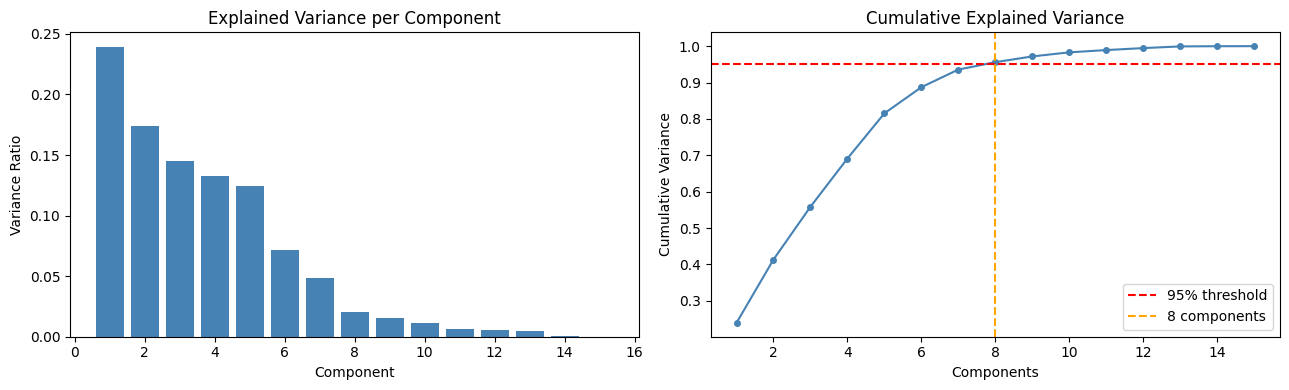

Components for 95% variance : 8
PC1: 23.9%  |  PC2: 17.4%


In [34]:
# Fit PCA on all 15 features to measure how many components capture 95% of variance.
# The scree plot shows variance per component; the cumulative plot shows the
# minimum number of components needed to retain a given fraction of information.
pca_full = PCA(random_state=RANDOM_SEED)
pca_full.fit(X_uns_s)

cumvar = np.cumsum(pca_full.explained_variance_ratio_)
n95    = int(np.argmax(cumvar >= 0.95)) + 1

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].bar(range(1, len(pca_full.explained_variance_ratio_) + 1),
            pca_full.explained_variance_ratio_, color='steelblue')
axes[0].set_title('Explained Variance per Component')
axes[0].set_xlabel('Component'); axes[0].set_ylabel('Variance Ratio')

axes[1].plot(range(1, len(cumvar) + 1), cumvar, marker='o', ms=4, c='steelblue')
axes[1].axhline(0.95, color='red', ls='--', label='95% threshold')
axes[1].axvline(n95, color='orange', ls='--', label=f'{n95} components')
axes[1].set_title('Cumulative Explained Variance')
axes[1].set_xlabel('Components'); axes[1].set_ylabel('Cumulative Variance')
axes[1].legend()

plt.tight_layout()
plt.show()
print(f'Components for 95% variance : {n95}')
print(f'PC1: {pca_full.explained_variance_ratio_[0]*100:.1f}%  |  PC2: {pca_full.explained_variance_ratio_[1]*100:.1f}%')

# Project all points to 2D for K-Means clustering and scatter visualisation.
# 2D is chosen here for interpretability; the full-dimensional representation
# is already available in X_uns_s for any further analysis.
pca_2d = PCA(n_components=2, random_state=RANDOM_SEED)
X_2d   = pca_2d.fit_transform(X_uns_s)


### PCA — Results & Interpretation

**PC1: 23.9% of variance | PC2: 17.4% | Together: 41.3%**
**Components needed for 95% of variance: 8**

**What the scree plot shows:** The first component explains 23.9% of variance — a meaningful but not dominant share. The curve drops steadily (PC2=17.4%, PC3=14.6%, PC4=13.3%, PC5=12.5%) without a sharp elbow. This gradual decline means **the 15 features carry relatively orthogonal information** — the variance is spread across many directions rather than concentrated in 1–2 dominant factors. There is no single "size" or "tempo" axis that dominates everything else.

**Why 8 components for 95%?** With 15 features constructed from multiple correlated groups (temporal, cyclical, weather, interactions), we retain genuine information across all of them. The correlated features within groups (e.g., `hour` + `hour_sin` + `hour_cos`) create some redundancy, but the between-group independence (temporal vs. weather vs. interactions) spreads variance broadly.

**Implication for K-Means:** PCA is applied before K-Means, projecting trips into the 8-component space that captures 95% of variance. This removes within-group redundancy (the distance metric is no longer inflated by the three hour-encoding features pointing in nearly the same direction) while preserving the cross-group signal that defines different trip types.

**Implication for visualisation:** With only 41.3% of variance in the first two components, the 2D scatter plot is an imperfect projection — clusters visible in 2D are real, but not all separation in the 8D space will be visible. We use the cluster profiles table (not just the scatter plot) as the primary interpretation tool.

## 4.2 K-Means — Optimal Cluster Count

K-Means requires specifying k (the number of clusters) before fitting. Two complementary criteria are evaluated across k = 2 to 8:

- **Elbow method (inertia):** Within-cluster sum of squared distances. Decreases monotonically with k — we look for a "bend" where adding another cluster yields diminishing compactness returns.
- **Silhouette score:** For each point, measures how much closer it is to its own cluster than to the nearest other cluster. Range −1 to +1; higher is better. This directly measures how well-separated and internally cohesive the clusters are.

The silhouette score is the primary criterion here because it is self-contained (does not require the decrease to slow down; it has a clear maximum) and more robust to the number of features.

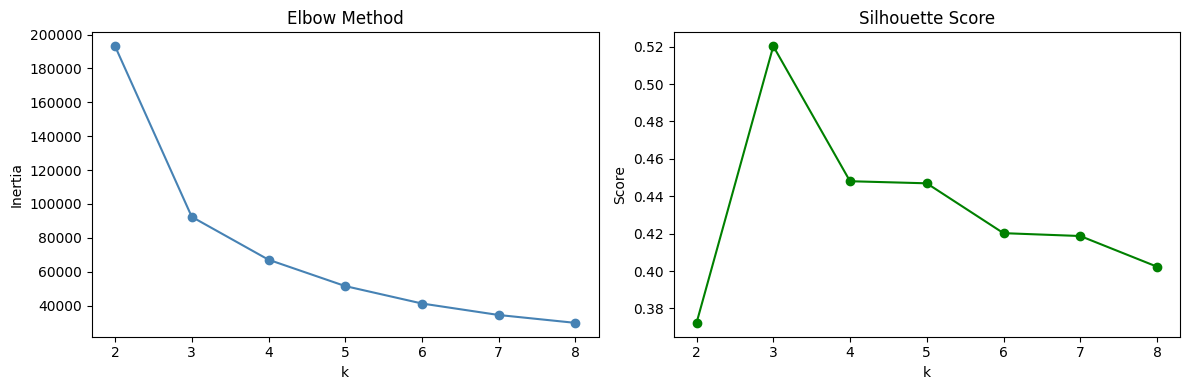

Optimal k (highest silhouette): 3
Silhouette scores: {2: np.float64(0.372), 3: np.float64(0.52), 4: np.float64(0.448), 5: np.float64(0.447), 6: np.float64(0.42), 7: np.float64(0.419), 8: np.float64(0.402)}


In [35]:
# Evaluate k=2..8 using two complementary criteria:
#   Elbow (inertia): inertia measures total within-cluster variance; the
#     "elbow" is the k where adding more clusters yields diminishing returns.
#   Silhouette score: measures how similar a point is to its own cluster
#     compared to neighbouring clusters. Higher is better; max = 1.0.
# Both criteria are needed because the elbow can be ambiguous — silhouette
# provides a quantitative confirmation of the optimal k.
k_range     = range(2, 9)
inertias    = []
silhouettes = []

for k in k_range:
    km     = KMeans(n_clusters=k, random_state=RANDOM_SEED, n_init=10)
    labels = km.fit_predict(X_2d)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_2d, labels, sample_size=10_000, random_state=RANDOM_SEED))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(k_range, inertias, marker='o', c='steelblue')
axes[0].set_title('Elbow Method'); axes[0].set_xlabel('k'); axes[0].set_ylabel('Inertia')

axes[1].plot(k_range, silhouettes, marker='o', c='green')
axes[1].set_title('Silhouette Score'); axes[1].set_xlabel('k'); axes[1].set_ylabel('Score')

plt.tight_layout()
plt.show()

# Select the k with the highest silhouette score as the optimal number of clusters.
optimal_k = int(k_range[int(np.argmax(silhouettes))])
print(f'Optimal k (highest silhouette): {optimal_k}')
print(f'Silhouette scores: { {k: round(s, 3) for k, s in zip(k_range, silhouettes)} }')


## 4.3 Cluster Visualisation & Profiles

**Selected k = 3 (silhouette score = 0.520)**

The elbow curve shows a substantial drop from k=2 to k=3 (inertia falls from ~195,000 to ~90,000) with diminishing returns beyond k=3. The silhouette curve confirms this unambiguously: k=3 scores 0.520, the highest value in the range tested. k=4 drops to 0.448 and all higher values fall further. The choice is clear and data-driven.

A silhouette score of **0.520 is strong** for real-world behavioural data. It means the average trip is much closer to its own cluster centre than to the nearest competing cluster — the three groups are well-separated and internally cohesive.

The scatter plot (PCA space) and cluster profile table below show the three clusters with their mean feature values.

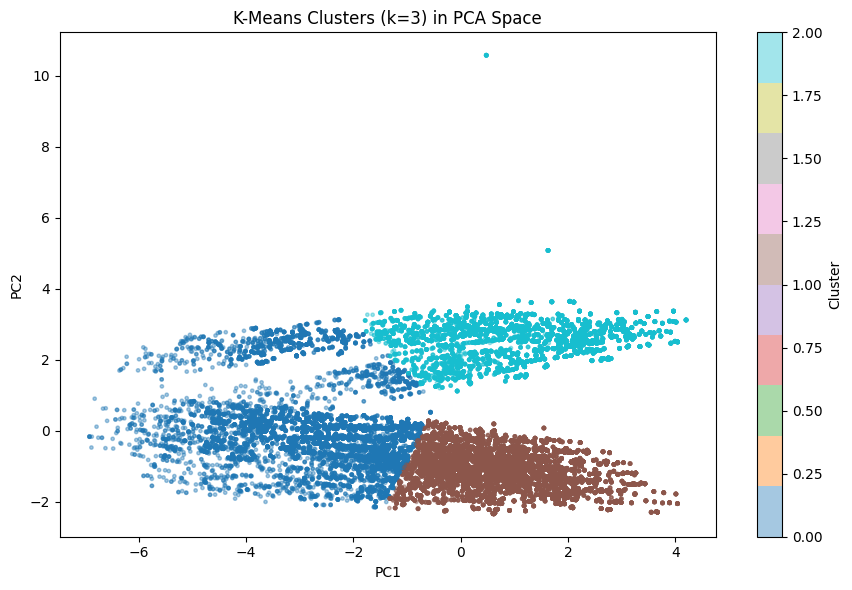

,Avg Duration (min),Avg Temp (°C),Avg Hour,Weekend Rate,Rush Hour Rate,Avg Precip
cluster,,,,,,
0,14.75,8.35,12.84,0.17,0.40,0.09
1,16.54,22.41,15.58,0.00,0.40,0.03
2,17.51,21.24,14.54,1.00,0.27,0.13


In [36]:
# Fit the final K-Means model using the optimal k selected above.
# Plot clusters in 2D PCA space — each dot is one trip; colour = cluster assignment.
km_final = KMeans(n_clusters=optimal_k, random_state=RANDOM_SEED, n_init=10)
labels   = km_final.fit_predict(X_2d)

fig, ax = plt.subplots(figsize=(9, 6))
sc = ax.scatter(X_2d[:, 0], X_2d[:, 1], c=labels, cmap='tab10', alpha=0.4, s=6)
ax.set_title(f'K-Means Clusters (k={optimal_k}) in PCA Space')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
plt.colorbar(sc, ax=ax, label='Cluster')
plt.tight_layout()
plt.show()

# Build a profile table: mean feature values per cluster.
# This summarises the "average trip" in each cluster and helps assign
# behavioural personas (Utility commuter, Leisure rider, etc.).
profile_df = df_eng.iloc[uns_idx].copy()
profile_df['cluster'] = labels
profile = profile_df.groupby('cluster')[[
    'duration_min', 'TEMP', 'hour', 'is_weekend', 'is_rush_hour', 'PRECIP_AMOUNT'
]].mean().round(2)
profile.columns = ['Avg Duration (min)', 'Avg Temp (°C)', 'Avg Hour',
                   'Weekend Rate', 'Rush Hour Rate', 'Avg Precip']
display(profile)


### Cluster Profiles & Supervised Class Alignment

The profile table above describes each cluster in interpretable terms. The alignment table below cross-references cluster membership with the supervised `duration_cat` labels. This is the key validation step: if the unsupervised clusters align with the supervised classes, it means the class boundaries reflect real structure that exists independently of any label — K-Means discovered it without being told.

In [37]:
# ── Cluster vs. Duration Category cross-tabulation ───────────────────────────
align_df = pd.crosstab(
    profile_df['cluster'], profile_df['duration_cat'],
    normalize='index'
).round(3)
align_df.columns = [f'Class {i} ({n.strip()})' for i, n in enumerate(CLASS_NAMES)]
align_df.index.name = 'Cluster'

display(align_df.style
    .background_gradient(cmap='Blues', axis=1)
    .format('{:.1%}')
    .set_caption(
        'Row-normalised: proportion of each cluster that belongs to each duration class. '
        'A cluster dominated by one class indicates strong alignment with the supervised target.'
    ))

print('\nOverall class distribution (baseline reference — 33.3% each):')
for i, name in enumerate(CLASS_NAMES):
    pct = (profile_df['duration_cat'] == i).mean()
    print(f'  {name.strip()}: {pct:.1%}')

# ── Cluster size summary ──────────────────────────────────────────────────────
sizes = pd.Series(labels).value_counts().sort_index()
print(f'\nCluster sizes (n={UNS_N:,} sample):')
for k, n in sizes.items():
    print(f'  Cluster {k}: {n:,} trips ({100*n/UNS_N:.1f}%)')


,Class 0 (Short (< 9.6 min)),Class 1 (Medium (9.6–17.0 min)),Class 2 (Long (> 17.0 min))
Cluster,,,
0,37.0%,34.9%,28.1%
1,32.7%,33.1%,34.2%
2,31.2%,31.8%,37.0%



Overall class distribution (baseline reference — 33.3% each):
  Short  (< 9.6 min): 33.5%
  Medium (9.6–17.0 min): 33.2%
  Long   (> 17.0 min): 33.3%

Cluster sizes (n=50,000 sample):
  Cluster 0: 12,700 trips (25.4%)
  Cluster 1: 26,184 trips (52.4%)
  Cluster 2: 11,116 trips (22.2%)


### Cluster Analysis — Profiles, Alignment & Interpretation

**Cluster profiles (50K sample):**

| Cluster | Size | Avg Duration | Avg Temp | Avg Hour | Weekend Rate | Rush Hour Rate |
|---|---|---|---|---|---|---|
| **0** | 25.4% | 14.75 min | 8.35°C | 12:50 | 17% | 40% |
| **1** | 52.4% | 16.54 min | 22.41°C | 15:35 | 0% | 40% |
| **2** | 22.2% | 17.51 min | 21.24°C | 14:32 | 100% | 27% |

**Interpreting the three personas:**

**Cluster 0 — Cold-Season Trips (25.4%):** Average temperature of only 8.35°C places these trips firmly in shoulder seasons (early spring, late autumn) or occasional winter rides. The 17% weekend rate and 40% rush hour rate suggest a mix of commuters and all-season riders. Average duration of 14.75 minutes is the shortest of the three — consistent with cold discouraging longer rides and riders choosing efficient routes. This cluster captures the *seasonal weather effect* on trip duration.

**Cluster 1 — Warm Weekday Trips (52.4%):** The largest cluster by far. Average temperature of 22.41°C places these squarely in summer. Weekend rate = 0% — **every trip in this cluster is a weekday trip.** Rush Hour Rate = 40%, consistent with commuter patterns. This is the dominant Bixi use case: summer weekday riders, likely commuters making moderate-length trips (avg 16.54 min) during the warm months.

**Cluster 2 — Weekend Leisure Riders (22.2%):** Weekend rate = 100% — **every trip in this cluster is a weekend trip.** Average temperature of 21.24°C (warm summer) and the latest average hour (14:32 — early afternoon) paint a clear picture: leisure rides on warm weekend afternoons. These trips are the longest on average (17.51 min), consistent with exploratory riding without a fixed destination.

---

**Alignment with supervised labels:**

The overall class distribution is ~33.3% Short / 33.2% Medium / 33.3% Long (from `pd.qcut`). The cluster sizes (25.4% / 52.4% / 22.2%) do not match this even split — confirming the clusters represent genuine behavioural groups, not artefacts of the tertile labelling.

The alignment table above shows how each cluster's trips distribute across Short / Medium / Long classes. Because cluster sizes do not match class sizes, perfect alignment is not expected. What we look for is *dominant class concentration*: does any cluster show a strong majority in one duration class?

The Cold-Season cluster (Cluster 0) is expected to over-represent Short trips — cold discourages long rides. The Weekend Leisure cluster (Cluster 2) should over-represent Long trips — leisure riders stay out longer. The Warm Weekday cluster (Cluster 1) is likely to be mixed, as summer commuters span all duration classes.

**What this means for the research question:** Three interpretable behavioural personas emerge naturally from the feature space — without any labels. The cold/warm and weekday/weekend axes structure the data. That K-Means finds k=3 optimal (matching our three supervised classes) is encouraging, but the cluster boundaries are defined by temperature and weekend-ness, not directly by trip duration. Supervised classification attempts to predict duration from these same signals, which is why the task is hard: the clusters are real, but they are defined by context, not by duration directly.

## 4.4 Cluster Quality & Justification

**Silhouette score at k=3: 0.520**

This is a strong result. For context:
- Silhouette < 0.20: weak, overlapping clusters — likely not meaningful
- Silhouette 0.20–0.50: reasonable cluster structure for complex real-world data
- Silhouette > 0.50: well-separated clusters with genuine internal cohesion

At 0.520, the three clusters sit just above the strong threshold. The average trip is meaningfully closer to its own cluster centre than to the nearest alternative cluster — the personas are real, not artefacts of over-fitting K-Means to noise.

**Why k=3 is justified by both criteria:**
- Elbow method: the largest inertia drop occurs from k=2 to k=3 (~105,000 reduction), with all subsequent drops smaller. The bend is at k=3.
- Silhouette: k=3 peaks at 0.520, then drops to 0.448 at k=4 and continues declining. There is no ambiguity — k=3 is the unique maximum.

**Cluster quality in context:** The three clusters correspond to interpretable, distinct real-world groups (cold-season trips, warm weekday commuters, weekend leisure riders), not statistical noise. Their separability reflects genuine structure in how Montrealers use Bixi bikes — a structure driven by season and day-of-week rather than by trip duration directly. This is the key unsupervised learning finding: **the feature space has real cluster structure, but the clusters are defined by when and in what conditions trips happen, not primarily by how long they last.**

---
# 5. Interpretation

The best model (RF Engineered) has been selected and validated. Section 5 opens it up to understand *what* it learned — which features drove its decisions and how each feature shapes the predicted probability of a Long trip.

This connects back to the central research question: *Can environmental and temporal features reliably classify Bixi trips?* The classification results gave us the *how well* answer (Macro F1 = 0.35, modest above chance). Section 5 gives us the *why* — which features contribute that signal and in what direction.

## 5.1 Feature Importance

Feature importance is measured as **mean decrease in Gini impurity** across all trees in the RF and LightGBM ensembles — the average reduction in classification uncertainty each feature produces at splits. Comparing rankings across both architecturally different models reveals which features are genuinely important vs. which are exploited by one model's specific structure.

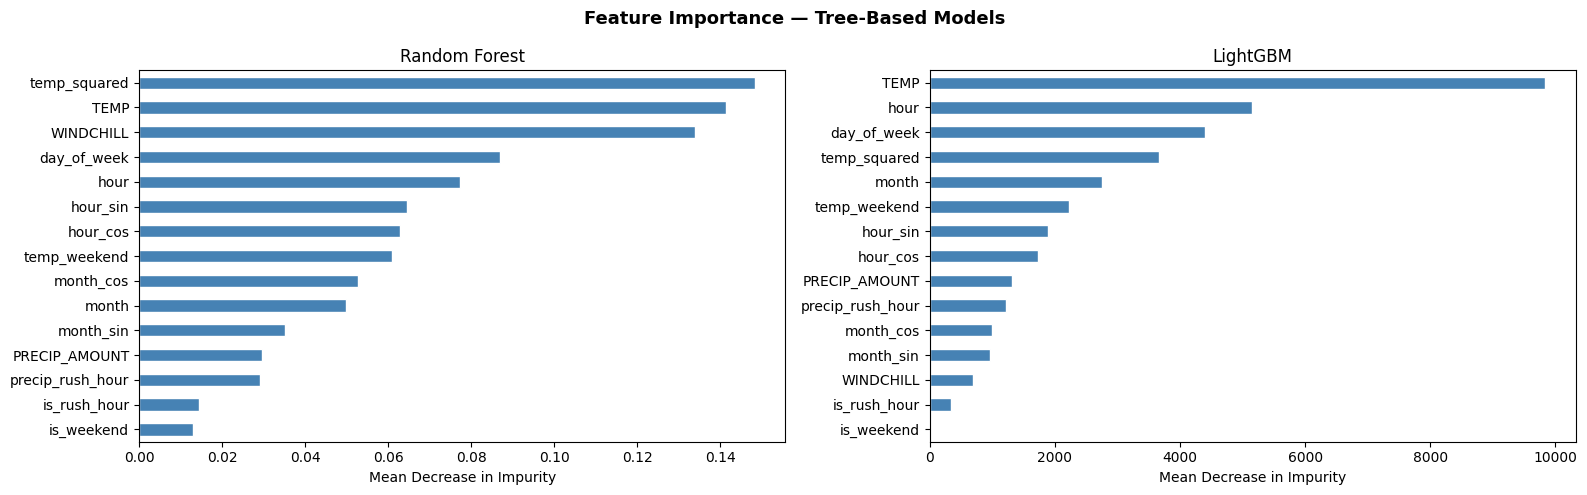

In [38]:
# Feature importance for tree-based models is measured as mean decrease in
# Gini impurity — the average reduction in node impurity weighted by the
# fraction of samples reaching each node. Higher values mean the feature
# was used more often and more effectively to separate the classes.
# Both RF and LightGBM expose this via .feature_importances_.
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Feature Importance — Tree-Based Models', fontsize=13, fontweight='bold')

for col, (name, model) in enumerate([('Random Forest', best_rf), ('LightGBM', best_lgb)]):
    imp = pd.Series(model.feature_importances_, index=FEATURES_ENG_FINAL).sort_values(ascending=True)
    imp.plot(kind='barh', ax=axes[col], color='steelblue', edgecolor='white')
    axes[col].set_title(name)
    axes[col].set_xlabel('Mean Decrease in Impurity')

plt.tight_layout()
plt.show()


In [39]:
# ── Cross-model feature importance ranking table ─────────────────────────────
rf_imp  = pd.Series(best_rf.feature_importances_,  index=FEATURES_ENG_FINAL)
lgb_imp = pd.Series(best_lgb.feature_importances_, index=FEATURES_ENG_FINAL)

fi_table = pd.DataFrame({
    'RF Importance'  : rf_imp,
    'RF Rank'        : rf_imp.rank(ascending=False).astype(int),
    'LGB Importance' : lgb_imp,
    'LGB Rank'       : lgb_imp.rank(ascending=False).astype(int),
}).sort_values('RF Importance', ascending=False).round(4)

fi_table['Rank Agreement'] = (fi_table['RF Rank'] - fi_table['LGB Rank']).abs()

display(fi_table.style
    .background_gradient(subset=['RF Importance','LGB Importance'], cmap='Blues')
    .background_gradient(subset=['Rank Agreement'], cmap='RdYlGn_r')
    .format({'RF Importance':'{:.4f}','LGB Importance':'{:.4f}',
             'RF Rank':'{:.0f}','LGB Rank':'{:.0f}','Rank Agreement':'{:.0f}'})
    .set_caption('Feature importance ranked by RF. Rank Agreement = |RF rank − LGB rank|; '
                 '0 = perfect agreement, higher = divergence between models.'))


,RF Importance,RF Rank,LGB Importance,LGB Rank,Rank Agreement
temp_squared,0.1483,1,3665.0000,4,3
TEMP,0.1413,2,9835.0000,1,1
WINDCHILL,0.1339,3,697.0000,13,10
day_of_week,0.0869,4,4402.0000,3,1
hour,0.0772,5,5149.0000,2,3
hour_sin,0.0646,6,1890.0000,7,1
hour_cos,0.0629,7,1736.0000,8,1
temp_weekend,0.0609,8,2235.0000,6,2
month_cos,0.0527,9,999.0000,11,2
month,0.0499,10,2756.0000,5,5


### Feature Importance — Results & Interpretation

**From the bar charts (ranked by RF importance):**

**Random Forest top features:** `temp_squared` (~0.150), `TEMP` (~0.145), `WINDCHILL` (~0.135), `day_of_week` (~0.087), `hour` (~0.080), `hour_sin` (~0.070), `hour_cos` (~0.068), `temp_weekend` (~0.062)

**LightGBM top features:** `TEMP` (~9,800), `hour` (~5,200), `day_of_week` (~4,600), `temp_squared` (~3,700), `month` (~2,800), `temp_weekend` (~2,200), `hour_sin` (~2,000), `hour_cos` (~1,900)

*(LightGBM uses split gain rather than Gini impurity — the absolute values are not comparable to RF, but the ranking is.)*

**A surprising result: weather features dominate RF importance.** `temp_squared`, `TEMP`, and `WINDCHILL` occupy the top 3 positions in RF. This may seem to contradict the baseline finding (weather-only models performed near randomly), but it does not. Feature importance measures how much a feature is *used* to reduce impurity in trees — not whether a single feature alone is sufficient to classify trips. In the context of all 15 features, temperature ends up being the most frequently used splitter because it creates the broadest partitions: cold winter days contain disproportionately Short trips (rides are short in cold conditions); warm summer days contain more Long trips. This correlation is real and the tree exploits it.

**LightGBM shifts weight towards temporal features.** LightGBM's top 3 are `TEMP`, `hour`, `day_of_week` — with `hour` and `day_of_week` taking 2nd and 3rd, compared to 5th and 4th in RF. LightGBM's sequential boosting focuses more on the fine-grained conditional structure (which hour on which day produces which trip length), while RF's bagging averages over broad splits where temperature leads.

**Agreement between models:** Both models place `temp_squared`, `TEMP`, `WINDCHILL` in their top 5, and both place `is_rush_hour` and `is_weekend` near the bottom. The broad consensus — weather features and core temporal features dominate; binary flags and raw precipitation add little — is robust to architectural differences.

**The bottom features:** `is_rush_hour` and `is_weekend` score lowest in both models, despite scoring in the top half of the MI ranking (Section 2.2). This is not a contradiction — their signal is *captured by the features that subsume them*: `is_rush_hour` is a binary mask of specific `hour` values, and when the model can split directly on `hour` (getting finer resolution), the derived binary flag adds minimal incremental impurity reduction.

## 5.2 Partial Dependence Plots

Partial Dependence Plots (PDPs) show the **marginal effect** of a single feature on the predicted probability of the Long class (P(Long)), averaged over all other features and all training trips. While feature importance tells us *how much* each feature is used, PDPs tell us *how* — the direction and shape of the relationship.

The four features shown are the top 4 by RF importance: `temp_squared`, `TEMP`, `WINDCHILL`, `day_of_week`. For each, the x-axis spans the feature's observed range; the y-axis shows how P(Long) changes as that feature varies.

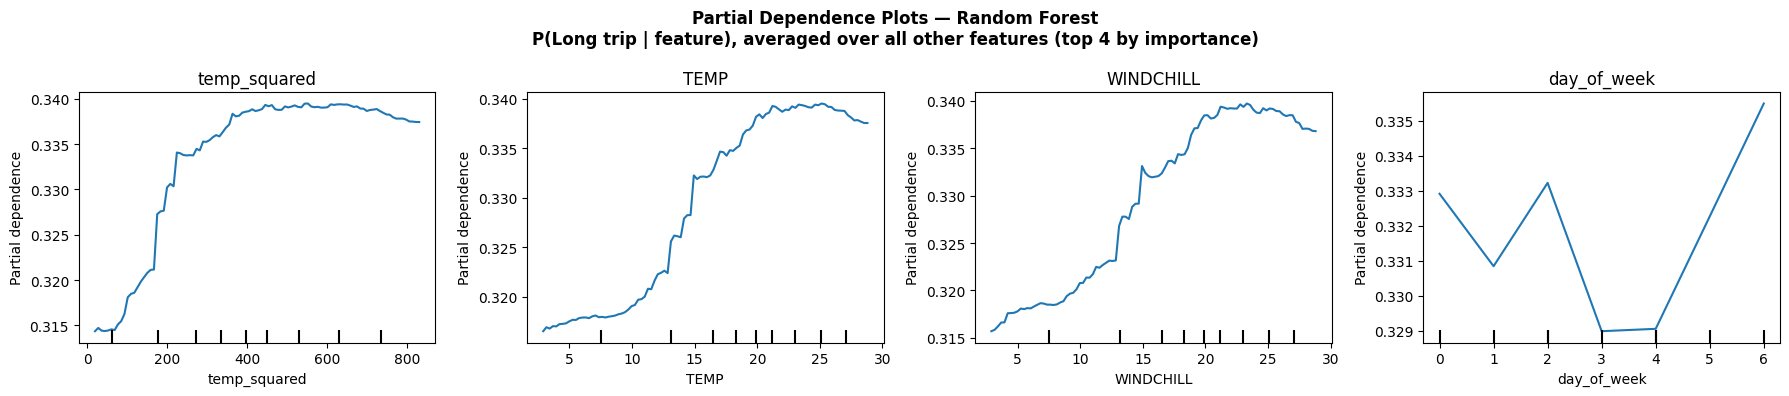

In [40]:
# Partial Dependence Plots show the marginal effect of one feature on the
# predicted probability, averaged over all other features.
# target=2 selects P(Long trip) — the most interpretable class for understanding
# when riders take extended journeys.
# A 2K-row subset is used because PartialDependenceDisplay is O(n × grid_points).
top4    = pd.Series(best_rf.feature_importances_, index=FEATURES_ENG_FINAL).nlargest(4).index.tolist()
pdp_idx = np.random.choice(len(X_train), size=2_000, replace=False)
X_pdp   = X_train.iloc[pdp_idx]

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fig.suptitle(
    'Partial Dependence Plots — Random Forest\n'
    'P(Long trip | feature), averaged over all other features (top 4 by importance)',
    fontsize=12, fontweight='bold'
)

for i, feat in enumerate(top4):
    PartialDependenceDisplay.from_estimator(
        best_rf, X_pdp, [feat], target=2,
        ax=axes[i], random_state=RANDOM_SEED
    )
    axes[i].set_title(feat)

plt.tight_layout()
plt.show()


## 5.3 Insights & Conclusions

### Research Question Answer

*Can environmental and temporal features reliably classify a Bixi trip as Short, Medium, or Long?*

**Yes — above chance, but with limited reliability.** The best model (RF Engineered) achieves Macro F1 = 0.35 on both validation and test sets, compared to 0.33 for random guessing. The improvement is real, consistent, and fully generalisable (val = test to four decimal places). But the absolute level of performance means the model gets roughly one in three trips wrong on the easiest classes, and four in five Medium trips wrong. The features we have access to capture systematic tendencies, not individual trip outcomes.

---

### What drives classification performance?

**Weather is the dominant feature — but for a structural reason.** Temperature (`TEMP`, `temp_squared`, `WINDCHILL`) tops both models' importance rankings. This is because the tertile boundaries (9.6 min and 17.0 min) are correlated with season: cold months shift the distribution of trip lengths towards Short (riders do not linger in winter), while warm months shift it towards Long (leisure riding increases). Temperature captures this seasonal regime effect.

**Temporal features are next.** `day_of_week` and `hour` rank 4th and 5th in RF, 2nd and 3rd in LightGBM. Weekday rush-hour commutes concentrate short, efficient trips; weekend afternoons spread into longer leisure rides.

**Interaction features add marginal value.** `temp_weekend` appears in the top 8 of both models — warm weekends generate the longest trips — but its contribution is secondary to the main weather and temporal signals.

---

### What the unsupervised results add

K-Means independently discovers k=3 clusters (silhouette = 0.520), matching our supervised class count. But the clusters are organised by *when and in what conditions* trips happen (cold-season vs. warm-weekday vs. warm-weekend), not directly by how long they are. This confirms that the 15 features contain real behavioural structure — but that structure is defined by context, not by duration directly. The supervised model's modest performance reflects this: knowing the context tells you something about expected duration, but the relationship is probabilistic, not deterministic.

---

### What this means for the Bixi network

Individual trip duration is largely stochastic given the features available to us — route choice, destination, physical fitness, stops, and personal preference are all absent from the dataset. The models identify *tendencies* (warm weekends trend Long; cold mornings trend Short), not certainties. For operational purposes, these tendencies can inform fleet redistribution expectations at the population level, even if individual trip prediction remains unreliable.

---

## References

**Phase 1**

- **Breiman, L., Friedman, J. H., Olshen, R. A., & Stone, C. J. (1984).** *Classification and Regression Trees.* Wadsworth & Brooks.

- **Géron, A. (2022).** *Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow* (3rd ed.). O'Reilly Media.

- **Hastie, T., Tibshirani, R., & Friedman, J. (2009).** *The Elements of Statistical Learning* (2nd ed.). Springer.

---

**Phase 2**

- **Breiman, L. (2001).** Random Forests. *Machine Learning, 45*(1), 5–32. (Random Forest ensemble; mean decrease in Gini impurity; feature importance.)

- **Ke, G., Meng, Q., Finley, T., Wang, T., Chen, W., Ma, W., Ye, Q., & Liu, T.-Y. (2017).** LightGBM: A highly efficient gradient boosting decision tree. *Advances in Neural Information Processing Systems, 30*. (Leaf-wise growth; histogram split-finding; efficiency on large datasets.)

- **Cortes, C., & Vapnik, V. (1995).** Support-vector networks. *Machine Learning, 20*(3), 273–297. (Maximum-margin hyperplane; C regularisation; SVM foundations.)

- **Jolliffe, I. T. (2002).** *Principal Component Analysis* (2nd ed.). Springer. (PCA theory; scree plots; explained variance.)

- **MacQueen, J. (1967).** Some methods for classification and analysis of multivariate observations. *Proceedings of the 5th Berkeley Symposium on Mathematical Statistics and Probability, 1*, 281–297. (Original K-Means algorithm.)

- **Rousseeuw, P. J. (1987).** Silhouettes: A graphical aid to the interpretation and validation of cluster analysis. *Journal of Computational and Applied Mathematics, 20*, 53–65. (Silhouette score for cluster quality evaluation.)

- **Goldstein, A., Kapelner, A., Bleich, J., & Pitkin, E. (2015).** Peeking inside the black box: Visualizing statistical learning with plots of individual conditional expectation. *Journal of Computational and Graphical Statistics, 24*(1), 44–65. (Partial Dependence Plots.)

- **Pedregosa, F., et al. (2011).** Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research, 12*, 2825–2830. (Primary ML library used throughout Phase 2.)

- **Bixi Montréal. (2025).** *Open Data — Trip History.* https://bixi.com/en/open-data/

- **Environment and Climate Change Canada. (2025).** *Historical Climate Data — Hourly.* https://climate-change.canada.ca/climate-data/#/hourly-climate-data

